# Шаг 0: Описание задачи




```
Задание 1: Карточка проекта
Название задачи: Анализ онлайн-рынка персональных компьютеров
Уровень сложности: Advanced
```
<table>
  <tr>
    <th>Бизнес-цель заказчика</th>
    <td>Выйти на онлайн-рынок в течение 3 месяцев с конкурентоспособными и востребованными сборками ПК, при этом снизить расходы на магазин, доставку и рекламу на 10%.</td>
  </tr>
  <tr>
    <th>Цель анализа данных</th>
    <td>Выявить зависимость цены и популярности (продаж) от технических характеристик ПК и построить модель предсказания цены для оптимизации будущих сборок.</td>
  </tr>
  <tr>
    <th>Объект исследования</th>
    <td>Персональные компьютеры, представленные на онлайн-площадках (за исключением мини-ПК и моноблоков)</td>
  </tr>
  <tr>
    <th>Предмет исследования</th>
    <td>Технические характеристики ПК, их цена и количество продаж на онлайн-площадке</td>
  </tr>
  <tr>
    <th>Контент, признаки данных</th>
    <td>
      Датасет содержит следующие признаки:<br>
      • product_id<br>
      • title<br>
      • price<br>
      • sales<br>
      • feedbacks<br>
      • seller<br>
      • seller_rating<br>
      • Процессор - объект python. Содержит "Тип процессора" и "Количество ядер"<br>
      • Оперативная память - объект python. Содержит "Тип оперативной памяти" и "Объем оперативной памяти"<br>
      • Жесткий диск - объект python. Содержит "Объем SSD" и "Объем HDD"<br>
      • Видеопроцессор<br>
      • Операционная система<br>
      • Гарантийный срок<br>
      • Страна производства<br>
      • Габариты и вес товара (с упаковкой и без). Объект Python
    </td>
  </tr>
  <tr>
    <th>Источники данных</th>
    <td>Датасет <code>wb_pc_hard.csv</code></td>
  </tr>
  <tr>
    <th>Временной период</th>
    <td>Не указан явно, но данные считаются актуальными на момент анализа</td>
  </tr>
  <tr>
    <th>Методы анализа</th>
    <td>
      • Описательная статистика<br>
      • Корреляционный анализ<br>
      • Визуализация данных (распределения, боксплоты, тепловые карты и др.)<br>
      • Построение регрессионной модели (линейная регрессия)
    </td>
  </tr>
  <tr>
    <th>Требования к результату анализа</th>
    <td>
      • Выводы о наиболее влияющих на цену и продажи характеристиках<br>
      • Рекомендации по сборкам ПК<br>
      • Модель прогнозирования цены<br>
      • Визуализации и таблицы для отчёта
    </td>
  </tr>
</table>




In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

import re
import ast

from scipy.stats import (
    mannwhitneyu, boxcox, shapiro, kruskal
)

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import PowerTransformer

In [ ]:
df = pd.read_csv('data/wb_pc_hard.csv')

# Шаг 1: Разведочный анализ

In [ ]:
df.sample(1)

,product_id,title,price,sales,feedbacks,seller,seller_rating,Процессор,Оперативная память,Жесткий диск,Видеопроцессор,Операционная система,Гарантийный срок,Страна производства,Габариты товара,Габариты товара (с упаковкой)
226,51262332,Игровой Компьютер Robotcomp Alligator Mini V1 ...,35086₽,Купили более 5 раз,3 отзыва,Robotcomp,4.7,"{'Процессор_тип': 'AMD Ryzen 5', 'Количество я...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",AMD Radeon Vega 7,windows пробная,3 Года (36 месяцев),Россия,"{'Ширина предмета': '13 см', 'Глубина предмета...","{'Длина упаковки': '48 см', 'Ширина упаковки':..."


In [ ]:
print(df.shape)
print('_____')
print(df.info())

(4500, 16)
_____
<class 'pandas.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product_id                     4500 non-null   int64  
 1   title                          4500 non-null   str    
 2   price                          4499 non-null   str    
 3   sales                          1164 non-null   str    
 4   feedbacks                      4500 non-null   str    
 5   seller                         4391 non-null   str    
 6   seller_rating                  4389 non-null   float64
 7   Процессор                      4500 non-null   str    
 8   Оперативная память             4500 non-null   str    
 9   Жесткий диск                   4500 non-null   str    
 10  Видеопроцессор                 4500 non-null   str    
 11  Операционная система           4500 non-null   str    
 12  Гарантийный срок               2648 non-nu

Датасет имеет 4500 наблюдений по 15 признакам. Seller_rating и product_id сразу имеют числовой формат. product_id и title можно сразу исключить. Габариты тоже исключим, потому что габариты по определению оказывают минимальное  влияние на  стоимость.

In [ ]:
df.drop(['product_id', 'Габариты товара', 'Габариты товара (с упаковкой)', 'title'], axis=1, inplace=True)

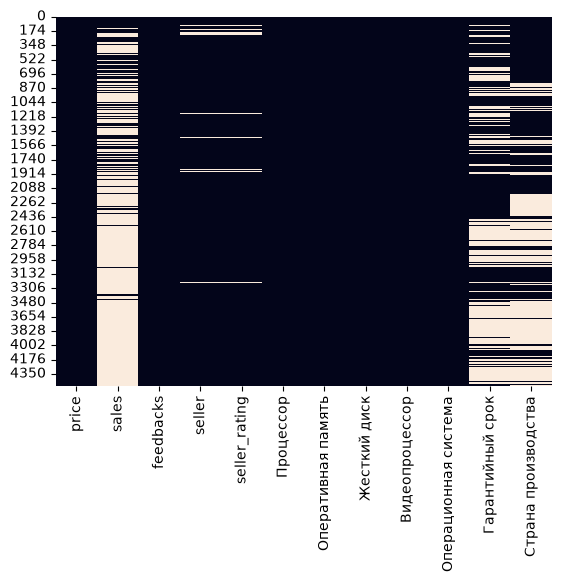

In [ ]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()

В sales очень много пропусков. Примем пропуски в этом признаке за отсутствие продаж. Все пропуски заменим на 0.
Наблюдения с пропусками в признаках seller и seller_rating для дальнейшего построения регресионной модели лучше исключить из датасета.
По признаку "Гарантийный срок" будем полагать, что пропуск означает отсутсвие гарантии. А поскольку в процессе очистки предполагается приведение этого признака к числовому, заменим все пропуски на 0.
По признаку "страна производства" заменим пропуски на "unknown".

Дальнейший анализ возможен только после очистки данных. Очистим  данные и закончим разведочный анализ данных в шаге 2.1 под блоком очистки данных.

# Шаг 2: Очистка данных

## Функции, используемые в решении задачи

In [ ]:
def new_predict(cores, sales, warranty, RAM, HDD, SSD, videocard, processor, seller): #функция для нового предсказания
  def rounder(num):
    return np.round(num, 6)

  cores_boxcox = boxcox(cores, boxcox_lambda)  # бокскоксим ядра

  sales_yj = transformers['sales'].transform(pd.DataFrame({'sales': [sales]}))[0][0] #по сохраненным трансформерам делаем трансформ.
  warranty_yj = transformers['Гарантийный срок'].transform(pd.DataFrame({'Гарантийный срок': [warranty]}))[0][0]
  RAM_yj = transformers['Объем оперативной памяти (Гб)'].transform(pd.DataFrame({'Объем оперативной памяти (Гб)': [RAM]}))[0][0]
  HDD_yj = transformers['Объем накопителя HDD'].transform(pd.DataFrame({'Объем накопителя HDD': [HDD]}))[0][0]
  SSD_yj = transformers['Объем накопителя SSD'].transform(pd.DataFrame({'Объем накопителя SSD': [SSD]}))[0][0]

  videocard_te = target_encoding_single(videocard, mappings_all['Видеопроцессор'], global_means_all['Видеопроцессор']) #вызываем функцию, которая вернет либосреднее группы, если она есть
  processor_te = target_encoding_single(processor, mappings_all['Тип процессора'], global_means_all['Тип процессора']) #либо глобальное среднее, если такой группы нет в маппинге
  seller_te = target_encoding_single(seller, mappings_all['seller'], global_means_all['seller'])

  features = list(map(rounder, [
      cores_boxcox, sales_yj, warranty_yj, RAM_yj,
      HDD_yj, SSD_yj, videocard_te,
      processor_te, seller_te
  ]))
  pred = model.predict([features])[0]

  return f"Прогнозируемая цена: {transformers['price'].inverse_transform([[pred]])[0][0].round(2)} руб."

In [ ]:
def target_encoding_single(value, mapping, global_mean): #таргет нового значения
    return mapping.get(value, global_mean)

In [ ]:
def check_normality(column, data, alpha=0.05,): #проверяет на соответсвие нормальному закону распределения
    p = shapiro(data[column].dropna()).pvalue
    print("Нормальное" if p > alpha else "Не нормальное")

In [ ]:
def clean_int(value): #очищает строки, оставляет числа
    digits = ''.join(c for c in str(value) if c.isdigit())
    return int(digits) if digits else 0

In [ ]:
def clean_float(value): #очищает строку, оставляет точку для флоата, меняет запятую, на точку
  if pd.isna(value): return value
  text = str(value).strip()
  return re.sub(r'[^\d.]', '', re.sub(r'[,]', '.', text))

In [ ]:
def target_encode(train_df, col, target, n_splits=5, smoothing=10):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    train_df[f'{col}_te'] = np.nan
    global_mean = train_df[target].mean()
    mappings = {}

    for train_idx, val_idx in kf.split(train_df):
        train_fold, val_fold = train_df.iloc[train_idx], train_df.iloc[val_idx]
        agg = train_fold.groupby(col)[target].agg(['mean', 'count'])
        smoothing_factor = 1 / (1 + np.exp(-(agg['count'] - smoothing)))
        smoothed_means = global_mean * (1 - smoothing_factor) + agg['mean'] * smoothing_factor

        train_df.loc[val_idx, f'{col}_te'] = val_fold[col].map(smoothed_means)
        mappings.update(smoothed_means.to_dict())

    train_df[f'{col}_te'] = train_df[f'{col}_te'].fillna(global_mean)
    return train_df, mappings, global_mean

## Из того, что мы видим: отзывы, гарантийный срок в int, цену и рейтинг во float, распарсить объекты пайтон по нескольким признакам.

## Парсинг "Процессор"

Парсим процессор. Сразу удаляем "не указано" в  "Тип процессора".

In [ ]:
df['Процессор'] = df['Процессор'].apply(ast.literal_eval)
df["Тип процессора"] = df["Процессор"].apply(lambda x: x.get("Процессор_тип"))
df["Количество ядер"] = df["Процессор"].apply(lambda x: x.get("Количество ядер процессора"))
df.drop(df[df['Тип процессора'] == 'не заполнено'].index, inplace = True)

Можем спасти некоторые записи, погуглив количество ядер. Но большинство спасти не удастся, потому что там не указаны модели, а указаны серии процессоров.

In [ ]:
mask = ((df['Тип процессора'] == 'Gemini Lake Refresh Processor J4125') |
 (df['Тип процессора'] == 'Intel Atom x5-Z8500') |
  (df['Тип процессора'] == 'Intel Processor N5095') |
   (df['Тип процессора'] == 'Intel J1800 2,0 GHz quad core')
   ) & (df['Количество ядер'] == 'не заполнено')
df.loc[mask, 'Количество ядер'] = '4'

In [ ]:
len(df[df['Количество ядер'] == 'не заполнено'])

20

Получилось спасти около 30 записей.


In [ ]:
df.drop(df[df['Количество ядер'] == 'не заполнено'].index, inplace=True)

In [ ]:
df.drop('Процессор', axis = 1, inplace = True)

In [ ]:
df['Тип процессора'].unique()

<StringArray>
[                            'Intel Celeron',
                             'Intel Core i5',
                             'Intel Core i3',
                               'AMD Ryzen 5',
                                'AMD Athlon',
                             'Intel Core i7',
                             'Intel Core i9',
                               'AMD Ryzen 3',
                 'Gemini Lake Refresh J4115',
                 'Gemini Lake Refresh J4125',
                         'Intel Core 12400F',
       'Gemini Lake Refresh Processor J4125',
                             'Intel Pentium',
                               'Intel J4125',
                                     'Intel',
                                'Intel Xeon',
                                      '6010',
                               'AMD Ryzen 7',
                                    '12400f',
                                    'AMD A6',
                                    '8 ядер',
                    

Сликшом много мусорных и повторяющихся(но написанных по-разному) категорий. Составим словаь для замен.


In [ ]:
df['Тип процессора'] = df['Тип процессора'].str.lower().str.strip()

cpu_dict = {
    # Intel Core i5
    'intel core i5': 'intel core i5',
    'intel core i 5': 'intel core i5',
    'intel corei5': 'intel core i5',
    'intel core i5-12400f': 'intel core i5',
    'intel core i5 10400f': 'intel core i5',
    'intel core i 5 10400f': 'intel core i5',
    'intel core 12400f': 'intel core i5',
    '12400f': 'intel core i5',

    # Intel Core i3
    'intel core i3': 'intel core i3',
    'intel core i 3': 'intel core i3',
    'intel corei3': 'intel core i3',
    'intel core i3 10100f': 'intel core i3',
    'intel core i 3 10100f': 'intel core i3',

    # Intel Core i7
    'intel core i7': 'intel core i7',

    # Intel Core i9
    'intel core i9': 'intel core i9',

    # Intel Atom
    'intel atom': 'intel atom',
    'intel atom x5-z8500': 'intel atom',
    'intel atom n280 (1.6 ггц)': 'intel atom',
    'intel atom n280': 'intel atom',
    'intel atom dualcore d2550 cedar trail': 'intel atom',
    'intel atom d2550': 'intel atom',

    # Intel Pentium
    'intel pentium': 'intel pentium',

    # Intel Xeon
    'intel xeon': 'intel xeon',
    'intel xeon e5': 'intel xeon',
    'intel xeon e3': 'intel xeon',
    'intel e3': 'intel xeon',
    'intel e5': 'intel xeon',

    # Gemini Lake и похожее
    'gemini lake refresh j4115': 'intel atom',
    'gemini lake refresh j4125': 'intel atom',
    'gemini lake refresh processor j4125': 'intel atom',
    'gemini lake refresh j3455': 'intel atom',
    'gemini lake j3455': 'intel atom',
    'gemini lake j4125': 'intel atom',
    'intel j4125': 'intel atom',
    'intel j4115': 'intel atom',
    'intel j3455': 'intel atom',
    'intel j1800 2,0 ghz quad core': 'intel atom',
    'intel j1800': 'intel atom',
    'intel apollo lake j3355 dual-core (2 ггц)': 'intel atom',
    'intel j3160': 'intel atom',
    'встроенный intel j3160 - core 1.5 ггц': 'intel atom',
    'intel z8350 4 ядра 1,92 ггц 64 бита': 'intel atom',
    'intel z8350': 'intel atom',
    'intel n5095': 'intel atom',
    'intel processor n5095': 'intel atom',
    'intel n5105': 'intel atom',

    # Intel Core Quad и похожие
    'intel core quad q9400': 'intel core quad',
    'intel core quad 9400': 'intel core quad',
    'q9400': 'intel core quad',
    'intеl quad q9400': 'intel core quad',
    'intеl quad 9400': 'intel core quad',
    'intеl quad': 'intel core quad',
    'intel core quad': 'intel core quad',

    # AMD Ryzen
    'amd ryzen 5': 'amd ryzen 5',
    'amd ryzen 3': 'amd ryzen 3',
    'amd ryzen 7': 'amd ryzen 7',
    'amd ryzen 9': 'amd ryzen 9',
    'amd ryzen 4600g vega7 арт. 100343717': 'amd ryzen 5',
    'amd ryzen 4600g vega7 арт. 143553804': 'amd ryzen 5',
    'amd ryzen 5 4600g': 'amd ryzen 5',
    'amd ryzen 5 5600x': 'amd ryzen 5',
    'amd ryzen 5 4650': 'amd ryzen 5',
    'amd ryzen 6': 'amd ryzen 6',
    'ryzen; 3 1300x': 'amd ryzen 3',
    'amd ryzen 3 1300x': 'amd ryzen 3',
    'amd рязань 5 5600x': 'amd ryzen 5',
    'amd рязань 5 4650': 'amd ryzen 5',

    # AMD E-series
    'amd e1-6010': 'amd e-series',

    # AMD A-series
    'amd a6': 'amd a-series',
    'amd a12-9800e': 'amd a-series',
    'amd a10-5800k': 'amd a-series',
    'amd a10': 'amd a-series',
    'amd a12': 'amd a-series',
    'a10-5800kram': 'amd a-series',

    # AMD FX
    'amd fx-4300': 'amd fx',
    'amd fx-6100': 'amd fx',

    # AMD Radeon

    # Apple
    'apple m1': 'apple m1',

    # ARM & Cortex
    'cortex-a53': 'cortex',
    'arm cortex-a53': 'cortex',

    # Misc / Garbage - удалить
    'amd radeon rx 570': 'DELETE',
    '6010': 'DELETE',
    '8 ядер': 'DELETE',
    '4 ядра intel': 'DELETE',
    'intel 4 ядра': 'DELETE',
    'unknown': 'DELETE',
    'intel': 'DELETE',
}

df['Тип процессора'] = df['Тип процессора'].replace(cpu_dict)

In [ ]:
df.drop(df[df['Тип процессора'] == 'DELETE'].index, inplace=True)

Слишком много категорий, чтобы отрисовать pie. Отрисуем гистограмму.

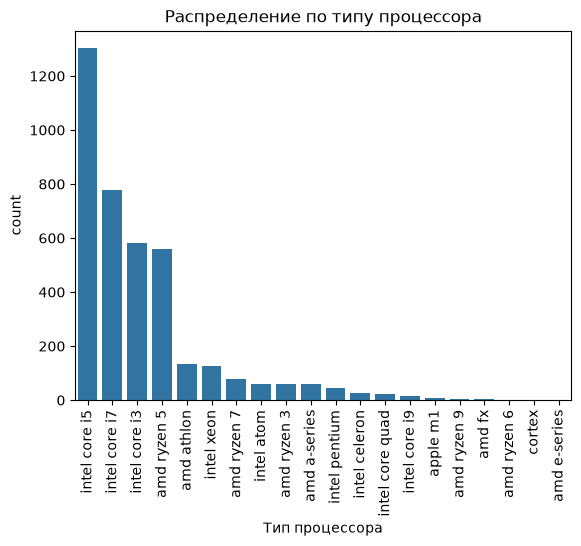

In [ ]:
sns.countplot(data=df, x='Тип процессора', order=df['Тип процессора'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Распределение по типу процессора')
plt.show()

К сожалению, на данном невозможно восстановить конкретные модели процессоров, потому что датасет изначально слишком грязный.

## Парсинг "Оперативная память"


In [ ]:
df['Оперативная память'] = df['Оперативная память'].apply(ast.literal_eval)
df["Тип оперативной памяти"] = df["Оперативная память"].apply(lambda x: x.get("Тип оперативной памяти"))
df["Объем оперативной памяти (Гб)"] = df["Оперативная память"].apply(lambda x: x.get("Объем оперативной памяти (Гб)"))

In [ ]:
df['Тип оперативной памяти'].unique()

<StringArray>
[       'DDR 3',        'DDR 4', 'не заполнено',          'DDR',
        'DDR 5',          '4Gb',           '16',        '16 Гб',
          '4GB',    'RAM 16 ГБ']
Length: 10, dtype: str

In [ ]:
df.drop(df[
    (df["Тип оперативной памяти"] == 'не заполнено') |
    (df["Тип оперативной памяти"] == 'DDR') |
    (df["Тип оперативной памяти"] == '4gb') |
    (df["Тип оперативной памяти"] == '16') |
    (df["Тип оперативной памяти"] == '16 Гб') |
    (df["Тип оперативной памяти"] == '4Gb') |
    (df["Тип оперативной памяти"] == '4GB') |
    (df["Тип оперативной памяти"] == 'SODDIM') |
    (df["Тип оперативной памяти"] == 'RAM 16 ГБ')
].index, inplace=True)

In [ ]:
df['Объем оперативной памяти (Гб)'].unique()

<StringArray>
[   '4 ГБ',       '8',      '16',   '16 ГБ',      '32',    '6 ГБ',    '8 ГБ',
   '32 ГБ',   '16 гб',    '16ГБ',       '4',      '64',    '8 GB',  '240 гб',
       '2',     '8Gb',       nan,   '64 ГБ',   '32 гб',    '8 гб',   '16 gb',
   '16 Гб', '1000 гб',   '64 гб',   '16 Gb']
Length: 25, dtype: str

Очистим данные, чтобы впоследствии привести к числовому типу.

In [ ]:
df['Объем оперативной памяти (Гб)'] = df['Объем оперативной памяти (Гб)'].apply(clean_int)

In [ ]:
df.drop('Оперативная память', axis = 1, inplace = True) #удаляем колонку, так как уже распарсили объекты

In [ ]:
df.drop(df[df['Объем оперативной памяти (Гб)'] == 1000].index, inplace=True) #это явный выброс, обработаем его на месте.

## Парсинг "Жесткий диск"

In [ ]:
df['Жесткий диск'] = df['Жесткий диск'].apply(ast.literal_eval)
df["Объем накопителя HDD"] = df["Жесткий диск"].apply(lambda x: x.get("Объем накопителя HDD"))
df["Объем накопителя SSD"] = df["Жесткий диск"].apply(lambda x: x.get("Объем накопителя SSD"))

In [ ]:
df["Объем накопителя HDD"].unique()

<StringArray>
[            nan,       '1000 Гб',       '2000 Гб',          '1 Тб',
          '1 тб',        '2000Gb',           '1Tb',           'нет',
           '2TB',          '1 TB',             '0',  'нет; без HDD',
       'без HDD',        '500 Gb',       '1000 Gb',           '500',
       '3000 гб',        '500 Гб',          '2 ТБ',        '500 гб',
        '512 Гб',   'Отсутствует',   'отсутствует',          '1000',
       '1000 гб',        '250 гб', '4000 Гб; 4000',        '1000GB',
   '500; 500 гб',       '2000 гб',       '1024 ГБ',          '2 тб']
Length: 32, dtype: str

In [ ]:
df['Объем накопителя HDD'] = df['Объем накопителя HDD'].apply(clean_int)

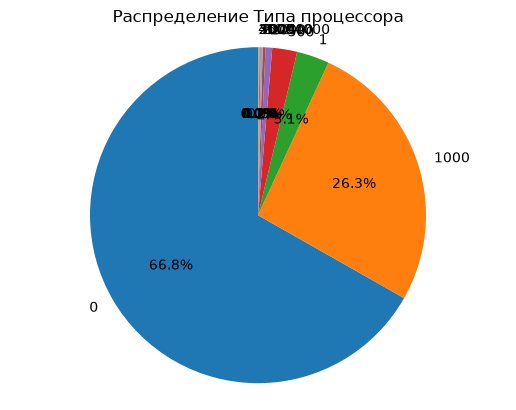

In [ ]:
plt.pie(df['Объем накопителя HDD'].value_counts(), labels=df['Объем накопителя HDD'].value_counts().index, autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.title('Распределение Типа процессора')
plt.show()

Неинформативно. Выведем .value_counts()

In [ ]:
print(df['Объем накопителя HDD'].value_counts())

Объем накопителя HDD
0           2513
1000         991
1            118
500           90
2000          24
512           10
2              7
1024           5
500500         2
3000           1
250            1
40004000       1
Name: count, dtype: int64


In [ ]:
df.loc[df['Объем накопителя HDD'].isin([1, 1000]), 'Объем накопителя HDD'] = 1024
df.loc[df['Объем накопителя HDD'].isin([2, 2000]), 'Объем накопителя HDD'] = 2048
df.loc[df['Объем накопителя HDD'] == 3000, 'Объем накопителя HDD'] = 3072
df.loc[df['Объем накопителя HDD'] == 250, 'Объем накопителя HDD'] = 256
df.loc[df['Объем накопителя HDD'] == 500, 'Объем накопителя HDD'] = 512

df = df[~df['Объем накопителя HDD'].isin([40004000, 500500])] #явные выбросы. удаляем

In [ ]:
df["Объем накопителя SSD"].unique()

<StringArray>
[                    nan,                '480 ГБ',                '960 Гб',
                '512 Гб',                  '2 Тб',                '240 Гб',
          '1000GB PCI-E',                '128 Гб',                '256 Гб',
                 '480Gb',                 '240Gb',                '120 ГБ',
                 '128GB',                 '256Gb',                 '120GB',
                 '512Gb',                 '500GB',                 '960Gb',
                   '512',                   '256',                '1000gb',
                '128 GB',                 '16 Гб',                  '2 Гб',
                 '64 Гб',                   '120',                '480 GB',
                '120 GB',                '240 GB',  '512Гб арт. 100343717',
                 '256гб',               '1000 Гб',                  '32Gb',
                  '64Gb',               '1024 гб',                '512 гб',
                '256 гб',                '240 гб',                '250 ГБ'

In [ ]:
df['Объем накопителя SSD'] = df['Объем накопителя SSD'].apply(clean_int)

In [ ]:
df["Объем накопителя SSD"].unique()

array([            0,           480,           960,           512,
                   2,           240,          1000,           128,
                 256,           120,           500,            16,
                  64,  512100343717,            32,          1024,
                 250,          1240,          1480,             1,
                2000,          5122,  512143553804,          1500,
              480960,        256960,          2561, 1000152611584])

In [ ]:
df.loc[df['Объем накопителя SSD'].isin([1, 1000, 1240, 960]), 'Объем накопителя SSD'] = 1024
df.loc[df['Объем накопителя SSD'].isin([2, 2000]), 'Объем накопителя SSD'] = 2048
df.loc[df['Объем накопителя SSD'].isin([500, 480]), 'Объем накопителя SSD'] = 512
df.loc[df['Объем накопителя SSD'].isin([250, 240]), 'Объем накопителя SSD'] = 256
df.loc[df['Объем накопителя SSD'].isin([120]), 'Объем накопителя SSD'] = 128
df.loc[df['Объем накопителя SSD'].isin([1480, 1500]), 'Объем накопителя SSD'] = 1536

In [ ]:
df = df[~df['Объем накопителя SSD'].isin([512100343717, 512143553804, 480960, 1000152611584, 256960, 2561, 5122])] #Тоже явные выбросы. удалим на месте

In [ ]:
df["Объем накопителя SSD"].unique()

array([   0,  512, 1024, 2048,  256,  128,   16,   64,   32, 1536])

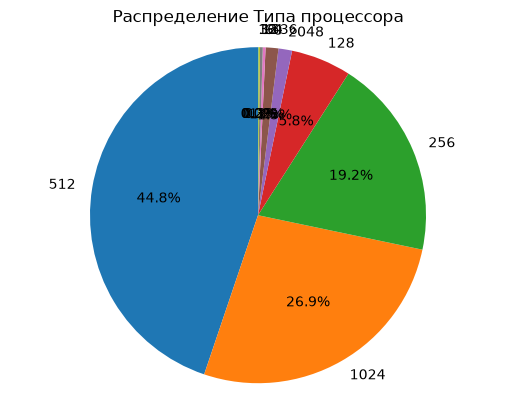

In [ ]:
plt.pie(df['Объем накопителя SSD'].value_counts(), labels=df['Объем накопителя SSD'].value_counts().index, autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.title('Распределение Типа процессора')
plt.show()

Тоже неинформативно. Опять выведем .value_counts().

In [ ]:
print(df['Объем накопителя HDD'].value_counts())

Объем накопителя HDD
0       2500
1024    1114
512      100
2048      31
3072       1
256        1
Name: count, dtype: int64


In [ ]:
df.drop('Жесткий диск', axis = 1, inplace = True) #удаляем распаршенный признак

## Очистка остальных данных

Сперва очистим цены, убрав символ валюты и, вызвав .describe(), проверим на наличие аномальных значений.

In [ ]:
df.loc[:,'price'] = df.loc[:,'price'].apply(clean_float)

In [ ]:
print(df['price'].describe())

count      3746
unique     1622
top       65630
freq         32
Name: price, dtype: object


Очистим продажи и отзывы

In [ ]:
df['sales'] = df['sales'].apply(clean_int)

In [ ]:
df['feedbacks'] = df['feedbacks'].apply(clean_int)

В видеокартах слишком много разных категорий. Если удалить этот пункт, то точность модели очень сильно пострадает, но если оставить его в текущем виде, то тоже ничего хорошего не будет. Надо найти золотую середину - оставить серии видеокарт. Это, безусловно,  снизит точность модели, но все же это единственный выход.

In [ ]:
df['Видеопроцессор'].unique()

<StringArray>
[          'Intel HD Graphics',      'Intel UHD Graphics 630',
     'NVIDIA GeForce GTX 1660',     'NVIDIA GeForce GTX 1650',
     'NVIDIA GeForce RTX 3070',     'NVIDIA GeForce RTX 3050',
           'AMD Radeon Vega 7',     'NVIDIA GeForce RTX 3080',
           'AMD Radeon Vega 3',     'NVIDIA GeForce RTX 3060',
      'NVIDIA GeForce GT 1030',      'intel UHD Graphics 750',
      'Intel HD Graphics 6000',       'Intel HD Graphics 600',
       'Intel HD Graphics 610',                'не заполнено',
       'NVIDIA GeForce GT 730',           'AMD Radeon Vega 8',
       'Intel HD Graphics 630',           'AMD Radeon RX 580',
     'NVIDIA GeForce GTX 1050',          'NVIDIA Quadro T400',
       'NVIDIA GeForce GT 740',     'NVIDIA GeForce RTX 2060',
      'Intel UHD Graphics 610',               'AMD Radeon R5',
       'Intel HD Graphics 500',     'NVIDIA GeForce GTX 1630',
           'AMD Radeon RX 550',          'AMD Radeon RX 6500',
      'Intel HD Graphics 2000',      'Int

In [ ]:
df.loc[:,'Видеопроцессор'] = df.loc[:,'Видеопроцессор'].str.lower().str.strip()

gpu_dict = {
    # Intel HD/UHD Graphics
    'intel hd graphics': 'intel hd graphics',
    'intel hd graphics 600': 'intel hd graphics',
    'intel hd graphics 610': 'intel hd graphics',
    'intel hd graphics 630': 'intel hd graphics',
    'intel hd graphics 6000': 'intel hd graphics',
    'intel hd graphics 500': 'intel hd graphics',
    'intel hd graphics 2000': 'intel hd graphics',
    'intel hd graphics 4000': 'intel hd graphics',
    'intel hd graphics 2500': 'intel hd graphics',
    'uhd graphics': 'intel uhd graphics',
    'intel uhd graphics 600': 'intel uhd graphics',
    'intel uhd graphics 605': 'intel uhd graphics',
    'intel uhd graphics 610': 'intel uhd graphics',
    'intel uhd graphics 620': 'intel uhd graphics',
    'intel uhd graphics 630': 'intel uhd graphics',
    'intel uhd graphics 730': 'intel uhd graphics',
    'intel uhd graphics 750': 'intel uhd graphics',

    # Nvidia GeForce
    'nvidia gtx 1660': 'nvidia gtx',
    'nvidia geforce gtx 1660': 'nvidia gtx',
    'nvidia gtx 1650': 'nvidia gtx',
    'nvidia geforce gtx 1650': 'nvidia gtx',
    'nvidia rtx 3070': 'nvidia rtx',
    'rtx 1650 4gb': 'nvidia rtx',
    'nvidia geforce rtx 3070': 'nvidia rtx',
    'nvidia rtx 3050': 'nvidia rtx',
    'nvidia rtx 3080': 'nvidia rtx',
    'nvidia rtx 3060': 'nvidia rtx',
    'nvidia gt 1030': 'nvidia gt',
    'nvidia geforce gt 1030': 'nvidia gt',
    'nvidia gt 730': 'nvidia gt',
    'nvidia geforce gt 730': 'nvidia gt',
    'nvidia quadro t400': 'nvidia quadro',
    'nvidia gt 740': 'nvidia gt',
    'nvidia geforce gt 740': 'nvidia gt',
    'nvidia rtx 2060': 'nvidia rtx',
    'nvidia geforce rtx 2060': 'nvidia rtx',
    'nvidia geforce rtx 3050': 'nvidia rtx',
    'nvidia geforce rtx 3080': 'nvidia rtx',
    'nvidia geforce rtx 3060': 'nvidia rtx',
    'nvidia geforce gtx 1630': 'nvidia gtx',
    'nvidia geforce gtx 1050': 'nvidia gtx',
    'nvidia gtx 1630': 'nvidia gtx',
    'nvidia rtx 4080': 'nvidia rtx',
    'nvidia geforce rtx 4080': 'nvidia rtx',
    'nvidia rtx 4070': 'nvidia rtx',
    'nvidia rtx 2080': 'nvidia rtx',
    'nvidia geforce rtx 2080': 'nvidia rtx',
    'nvidia gtx 1060': 'nvidia gtx',
    'nvidia geforce gtx 1060': 'nvidia gtx',
    'nvidia geforce rtx 1660': 'nvidia gtx',
    'nvidia geforce rtx 4070': 'nvidia gtx',
    'nvidia gtx 970': 'nvidia gtx',
    'nvidia geforce gtx 970': 'nvidia gtx',
    'nvidia gtx 650': 'nvidia gtx',
    'nvidia geforce gtx 650': 'nvidia gtx',

    # AMD Radeon
    'amd vega 7': 'amd vega',
    'amd radeon vega 8': 'amd vega',
    'amd radeon vega 7': 'amd vega',
    'amd radeon vega 6': 'amd vega',
    'amd radeon vega 3': 'amd vega',
    'vega': 'amd vega',
    'amd vega 8': 'amd vega',
    'amd vega 6': 'amd vega',
    'amd vega 3': 'amd vega',
    'amd rx 580': 'amd rx',
    'amd radeon rx 580': 'amd rx',
    'amd radeon rx 550': 'amd rx',
    'amd rx 550': 'amd rx',
    'amd rx 6500': 'amd rx',
    'amd radeon rx 6500': 'amd rx',
    'amd radeon rx 570': 'amd rx',
    'amd radeon rx 6600': 'amd rx',
    'amd radeon rx 6700': 'amd rx',
    'amd rx 6600': 'amd rx',
    'amd rx 470': 'amd rx',
    'amd rx 460': 'amd rx',
    'amd radeon rx 470': 'amd rx',
    'rx 460': 'amd rx',
    'amd radeon r5': 'amd radeon',
    'radeon r7 350': 'amd radeon',
    'radeon rx580 8gb': 'amd radeon',
    'amd radeon r7 350': 'amd radeon',
    'amd rx 6700': 'amd rx',

    # Garbage / unknown / to delete
    'unknown': 'DELETE',
    'не заполнено': 'DELETE',
    'amd': 'DELETE',
    'nvidia': 'DELETE',
    'invidia': 'DELETE',
    'nvidia geforce': 'DELETE',
    'intel': 'DELETE',
    'intel core i3 10105f 3.7ггц': 'DELETE',
    'intel core i3 10105f': 'DELETE',
    'intel core i5 11400f 2.6ггц': 'DELETE',
    'uhd-графика intel 630': 'DELETE',
    'delete': 'DELETE',

}

df.loc[:,'Видеопроцессор'] = df.loc[:,'Видеопроцессор'].replace(gpu_dict)

In [ ]:
df.drop(df[df['Видеопроцессор'] == 'DELETE'].index, inplace=True)

In [ ]:
df['Видеопроцессор'].unique()

<StringArray>
[ 'intel hd graphics', 'intel uhd graphics',         'nvidia gtx',
         'nvidia rtx',           'amd vega',          'nvidia gt',
             'amd rx',      'nvidia quadro',         'amd radeon']
Length: 9, dtype: str

Перейдем к ОС. Я сформирую новую категорию : other. К ней будут относится все trial версии и DOS. В блоке "Статический анализ" проверим гипотезу:

Н0 (нулевая гипотеза):
Категория «other» (trial версии и DOS) не влияет на целевую переменную — её распределение совпадает с остальными категориями ОС.

Н1 (альтернативная гипотеза):
Категория «other» (trial версии и DOS) влияет на целевую переменную — её распределение отличается от остальных категорий ОС.



In [ ]:
df['Операционная система'].unique()

<StringArray>
[           'отсутствует',        'windows пробная',         'Windows 10 Pro',
        'Windows 10 Home',                'Windows',             'Windows 10',
 'Windows 11 Pro (Trial)',  'Windows 7/8/10, LINUX',         'Windows 11 Pro',
               'Free DOS', 'Windows пробная версия',        'Windows 11 Home',
       'windows 10 trial',     'Windows 10 пробная',   'Windows 10 Pro Trial',
             'Windows 11',             'windows 10',   'Microsoft Windows 11',
    'Window 10 Pro trial',                    'DOS',   'Windows 10 pro Trial',
             'WINDOWS 10',                 'Без OC']
Length: 23, dtype: str

In [ ]:
df.loc[:,'Операционная система'] = df.loc[:,'Операционная система'].str.lower().str.strip()

os_dict = {
    #10
    'windows 10 pro':'windows 10',
    'windows 10 home':'windows 10',

    #11
    'windows 11 pro':'windows 11',
    'windows 11 home':'windows 11',
    'microsoft windows 11':'windows 11',

    #Остальное
    'windows 11 pro (trial)':'Other',
    'windows 10 trial':'Other',
    'windows 10 пробная':'Other',
    'window 10 pro trial':'Other',
    'windows 10 pro trial':'Other',
    'windows пробная':'Other',
    'windows':'windows 7/8/10',
    'windows пробная версия':'Other',
    'windows 7/8/10':'windows 7/8/10',
    'windows 7/8/10, linux':'Other',
    'free dos':'Other',
    'dos':'Other',

  #Отсутствет
    'без oc':'отсутствует',
    }

df.loc[:,'Операционная система'] = df.loc[:,'Операционная система'].replace(os_dict)

In [ ]:
print(df['Операционная система'].value_counts())

Операционная система
windows 10        2377
windows 11         703
Other              381
отсутствует        100
windows 7/8/10      26
Name: count, dtype: int64


Перейдем к гарантийному сроку. Точно так же, как и раньше: создадим словарь замен.

In [ ]:
df['Гарантийный срок'].unique()

<StringArray>
[                  '3года',     '3 Года (36 месяцев)',
                  '6 мес.',                  '3 года',
                       nan,                  '36 мес',
              '36 месяцев',                  '24 мес',
                  '12 мес',                   '6 мес',
              '12 месяцев',               '24 месяца',
                   '1 год',                 '12 мес.',
                  '2 года',               '6 месяцев',
                 '36 мес.',                '3 месяца',
                       '1',                 '14 дней',
           '1 год; 12 мес',       '1 год; 12 месяцев',
 '12 месяцев от King Komp', '12 месяцев от KING KOMP',
      '1 год (12 месяцев)']
Length: 25, dtype: str

In [ ]:
df['Гарантийный срок'] = df['Гарантийный срок'].str.lower().str.strip()

time_dict = {
    '3 года': 36,
    '3года': 36,
    '3 года (36 месяцев)': 36,
    '36 месяцев': 36,
    '36 мес': 36,
    '36 мес.': 36,
    '2 года': 24,
    '24 месяца': 24,
    '24 мес': 24,
    '12 месяцев': 12,
    '12 мес': 12,
    '12 мес.': 12,
    '6 месяцев': 6,
    '6 мес': 6,
    '6 мес.': 6,
    '3 месяца': 3,
    '1 год': 12,
    '1 год (12 месяцев)': 12,
    '1': 12,
    '14 дней': 1,
    '1 год; 12 мес': 12,
    '1 год; 12 месяцев': 12,
    '12 месяцев от king komp': 12,
    '12 месяцев от king komp': 12,
    'nan': 0,
    np.nan: 0,
}

df['Гарантийный срок'] = df['Гарантийный срок'].replace(time_dict)

In [ ]:
print(df['Гарантийный срок'].value_counts())

Гарантийный срок
36    1423
0     1327
12     776
24      49
6        8
3        2
1        2
Name: count, dtype: int64


## Удаление дубликатов, очистка пропусков

Удалим дубликаты

In [ ]:
df = df.drop_duplicates()

Очистим пропуски в цене и в рейтинге продавца.

In [ ]:
df = df.dropna(subset=['price', 'seller_rating'])

Заполним пропуски в "Страна производства" значением "unknown".

In [ ]:
df.loc[:,'Страна производства'] = df.loc[:,'Страна производства'].fillna('unknown')

In [ ]:
len(df[df['Страна производства'] == 'Беларусь'])

5

Поскольку значение "Беларусь" в стране производства имеет только 5 наблюдений, то выкинем ее в unknown, чтобы потом проще было строить регрессию. Многого мы не потеряем, все равно 5 наблюдений - слишком малая выборка.

In [ ]:
df.loc[df['Страна производства'] == 'Беларусь', 'Страна производства'] = 'unknown'

## Приведем данные к типам

In [ ]:
df['price'] = df['price'].astype(float)
df['sales'] = df['sales'].astype(int)
df['Гарантийный срок'] = df['Гарантийный срок'].astype(int)
df['Количество ядер'] = df['Количество ядер'].apply(clean_int)
df['feedbacks'] = df['feedbacks'].astype(int)

Очистим индексы.

In [ ]:
df.reset_index(inplace = True, drop = True)

После очистки потеряли около 2.4к записей


Итоги очистки данных: были удалены дубликаты, обработаны пропуски, рапспарсены объекты, корректно обработаны категориальные данные и признаки были приведены к необходимым типам. Датасет принял вид:


In [ ]:
df.sample(1)

,price,sales,feedbacks,seller,seller_rating,Видеопроцессор,Операционная система,Гарантийный срок,Страна производства,Тип процессора,Количество ядер,Тип оперативной памяти,Объем оперативной памяти (Гб),Объем накопителя HDD,Объем накопителя SSD
840,27706.0,5,1,D-Tora,4.1,intel hd graphics,windows 10,12,Россия,intel core i3,4,DDR 3,16,0,512


# Шаг 2.1: Продолжение разведочного анализа

## Проверка гипотезы о зависимости групп ОС от целевого признака

В блоке "Очистка данных" была сформуирована гипотеза:

Н0 (нулевая гипотеза): Категория «other» (trial версии и DOS) не влияет на целевую переменную — её распределение совпадает с остальными категориями ОС.

Н1 (альтернативная гипотеза): Категория «other» (trial версии и DOS) влияет на целевую переменную — её распределение отличается от остальных категорий ОС.

Для проверки данной гипотезы планируется провести сравнительный анализ средних цен в соответствующих группах с использованием t-теста или критерия Шапиро-Уилка

In [ ]:
main_os = ['отсутствует', 'windows 10', 'windows 7/8/10', 'windows 11']
df_main_os = df[df['Операционная система'].isin(main_os)].copy()

df_other_os = df[df['Операционная система'] == 'Other'].copy()

stat_main, p_main = shapiro(df_main_os['price'])
stat_other, p_other = shapiro(df_other_os['price'])

print('Статистика main:', stat_main)
print('p-значение main:', p_main)
print('Статистика other:', stat_other)
print('p-значение other:', p_other)

Статистика main: 0.900850890732718
p-значение main: 9.083050464479737e-31
Статистика other: 0.858175019913571
p-значение other: 2.9817613140533163e-15


Используем Шапиро-Уилка, Данные не соответсвуют нормальному закону распределения

In [ ]:
stat, p = mannwhitneyu(df_main_os['price'], df_other_os['price'], alternative='two-sided')

print('Статистика Манна-Уитни:', stat)
print('p-значение:', p)

Статистика Манна-Уитни: 211700.5
p-значение: 0.42336529901068465


Статистически значимой разницы между группами нет. P-Value 0.57. Нет оснований отвергнуть Н0. Значит, допускается выделение DOS и trial версий в отдельную категорию.

## Визуализация распределений

## Числовые

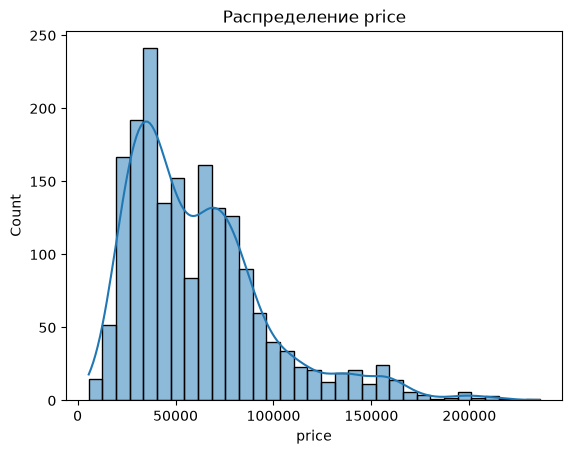

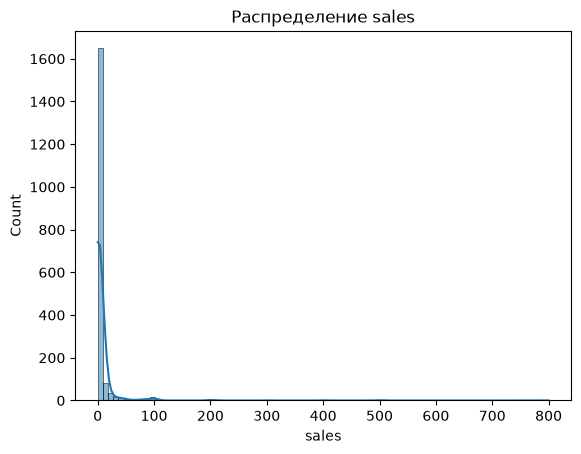

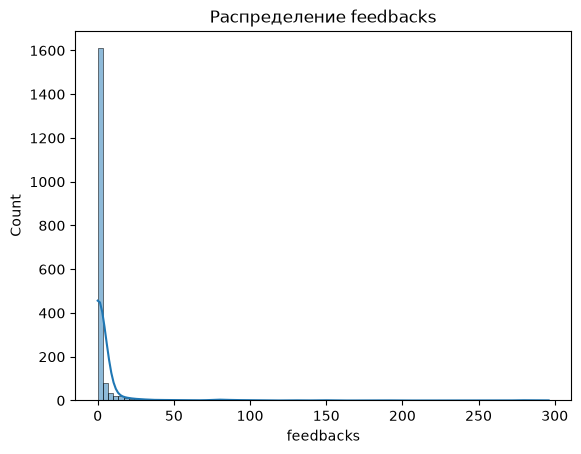

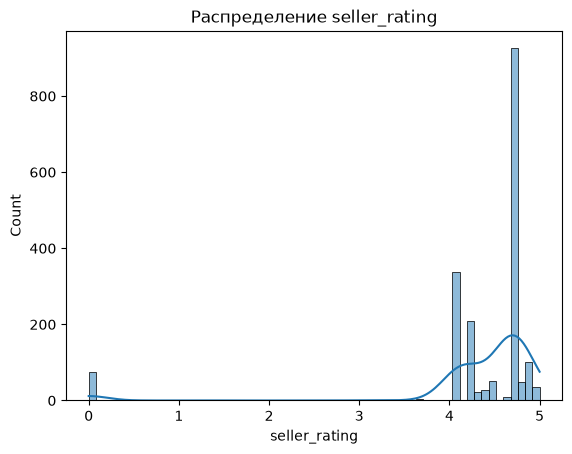

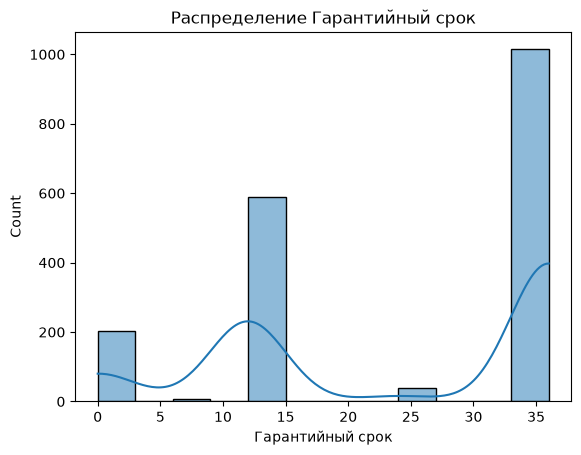

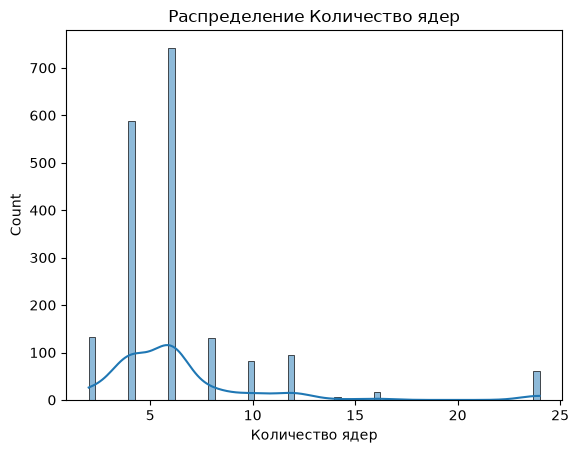

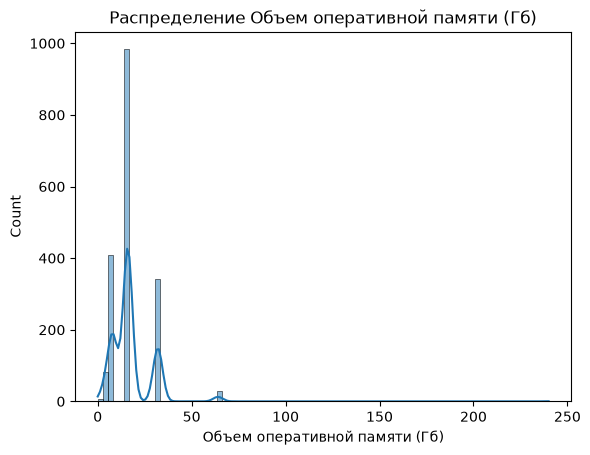

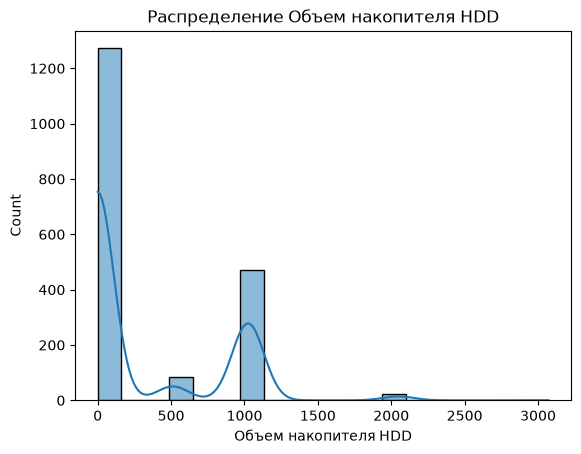

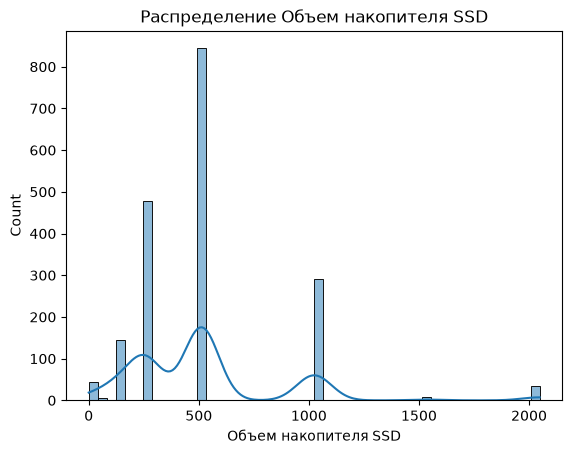

In [ ]:
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    sns.histplot(df[col], kde=True)
    plt.title(f'Распределение {col}')
    plt.show()

## Категориальные

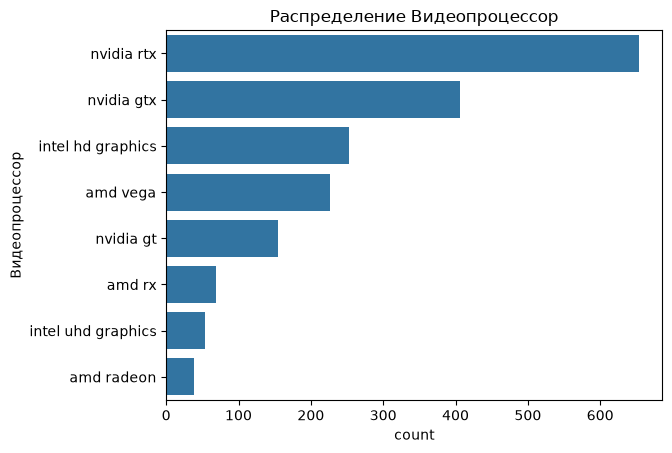

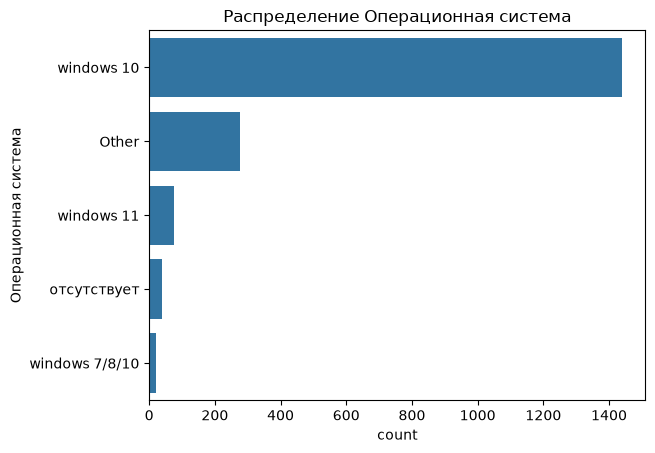

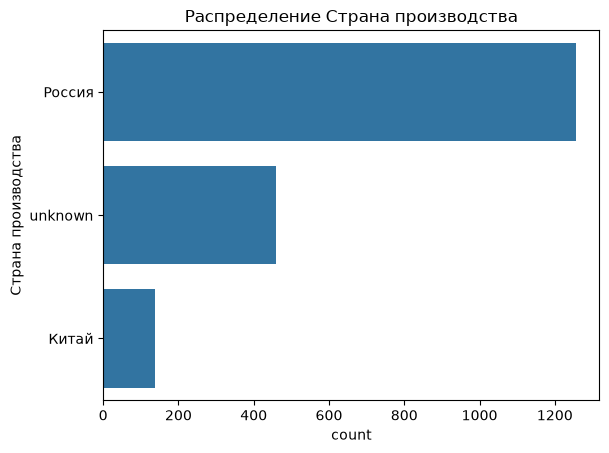

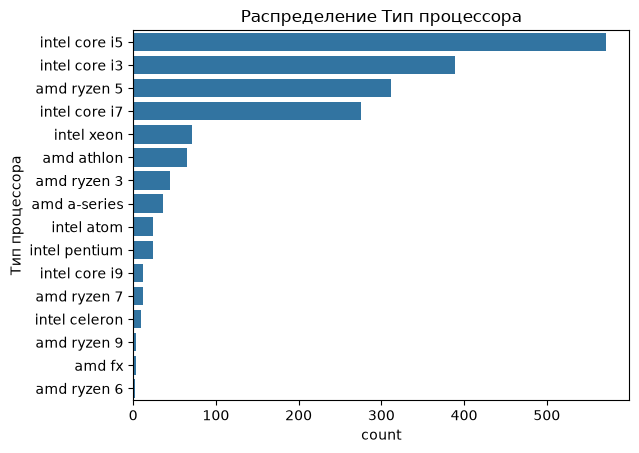

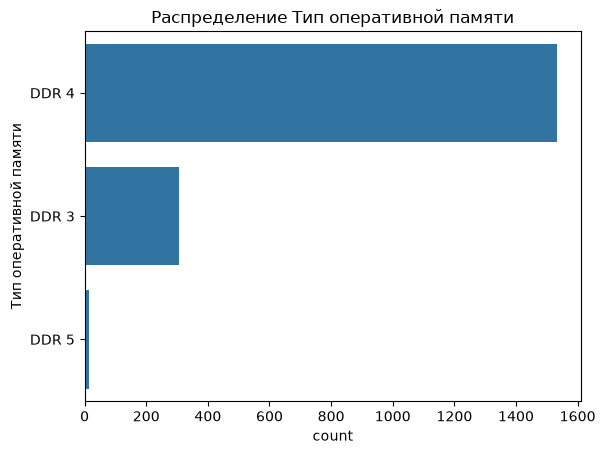

In [ ]:
for col in ['Видеопроцессор','Операционная система', 'Страна производства', 'Тип процессора', 'Тип оперативной памяти']:
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Распределение {col}')
    plt.show()

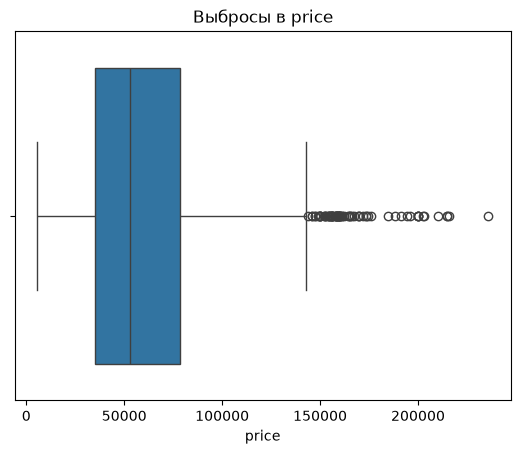

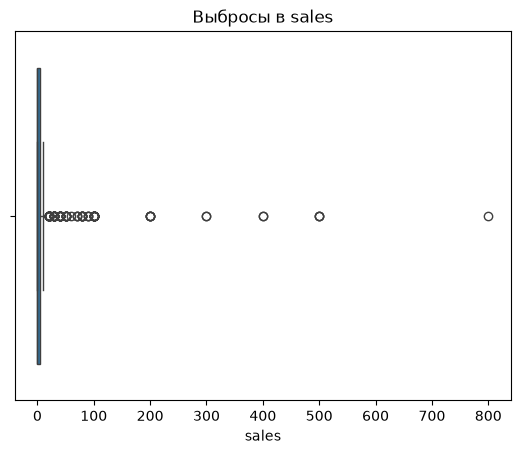

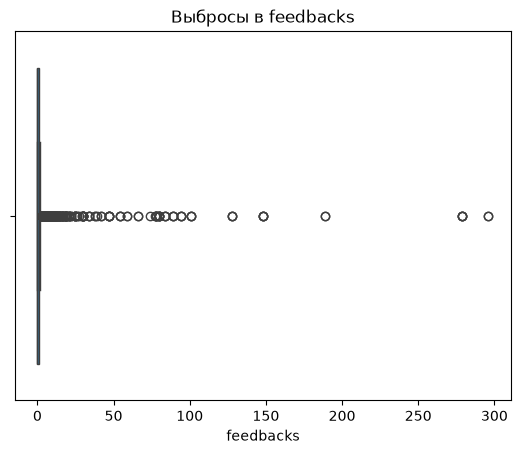

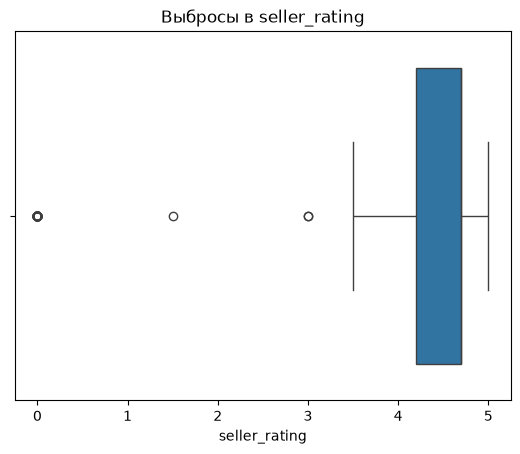

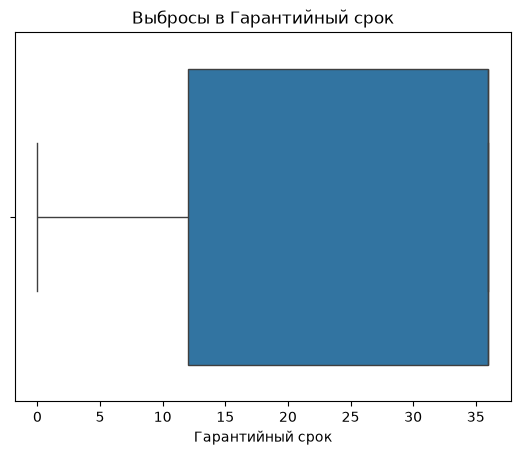

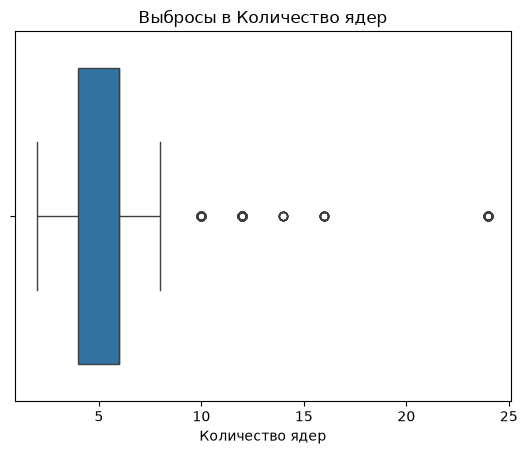

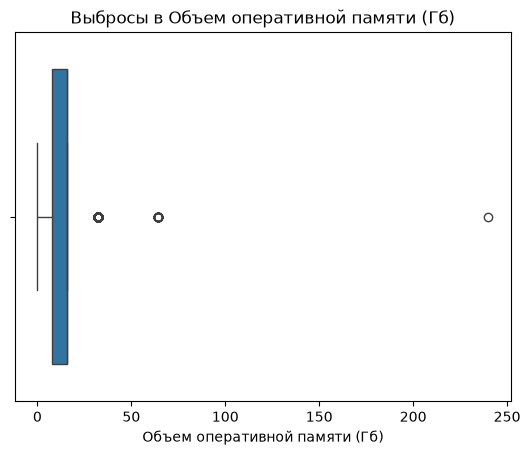

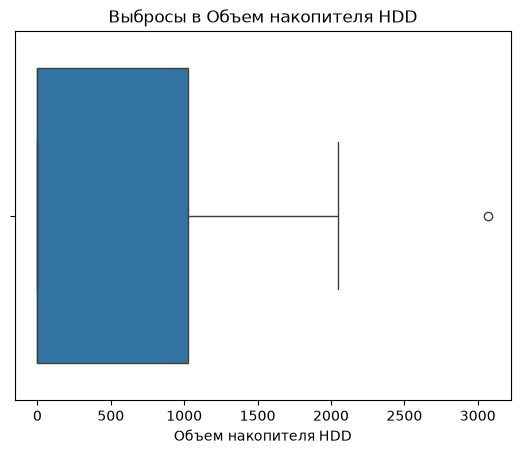

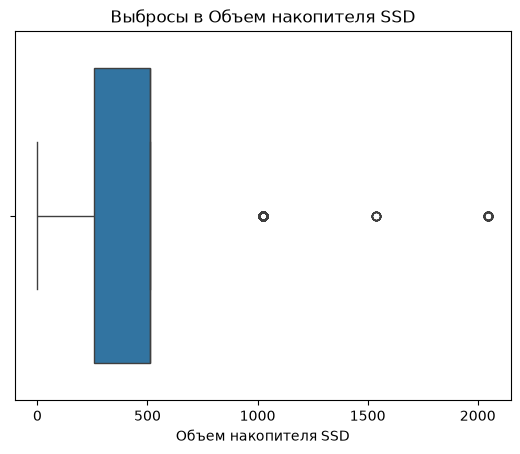

In [ ]:
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    sns.boxplot(x=df[col])
    plt.title(f'Выбросы в {col}')
    plt.show()

«Во всех признаках наблюдаются выбросы. В дальнейшем для нормализации распределения данных планируется применение трансформаций, таких как Box-Cox и Yeo-Johnson.»

## Анализ количественных признаков

Построим тепловую карту зависимостей количественных признаков

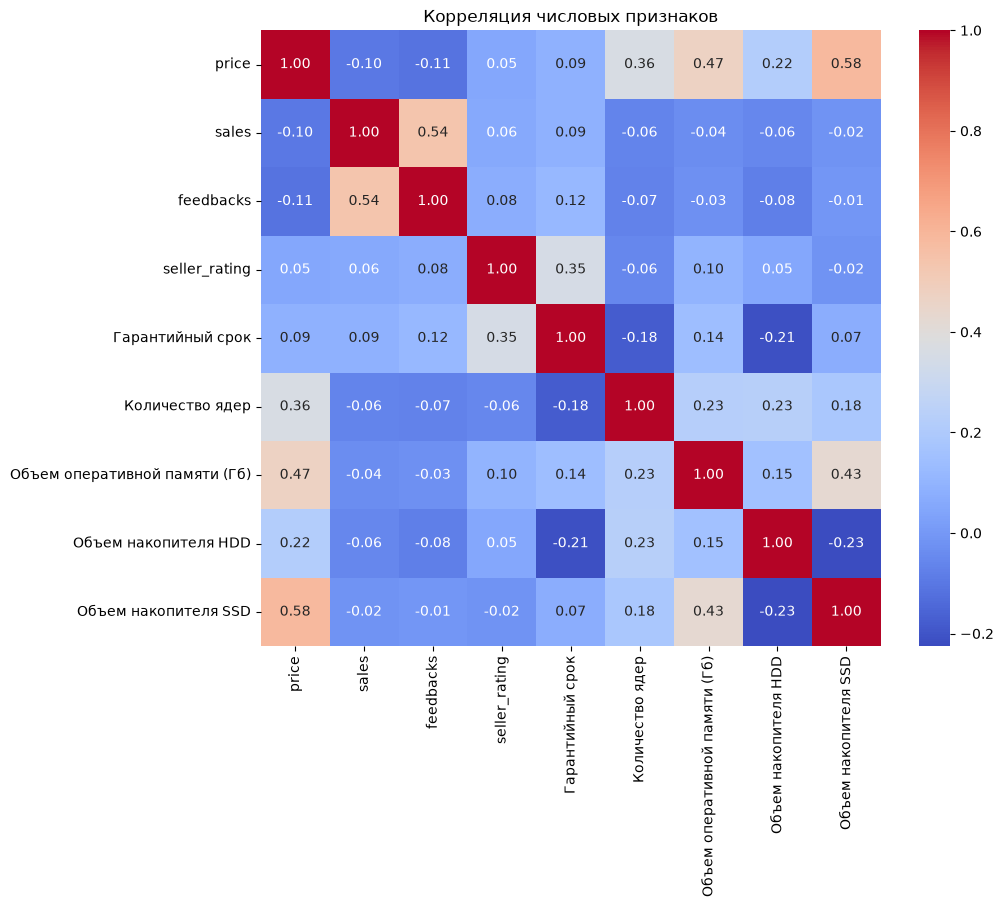

In [ ]:
num_df = df.select_dtypes(include=['int64', 'float64'])
corr = num_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Корреляция числовых признаков')
plt.show()

Видим зависимость sales от количества ядер — слабая, от объема оперативной памяти — умеренная, от объема накопителя HDD — слабая, а от объема SSD — сильная. Также сильная зависимость sales от количества отзывов (feedbacks). От объема оперативной памяти и SSD наблюдается умеренная связь. Интересно, что есть слабая обратная зависимость объема HDD от гарантийного срока.

В данных много выбросов по sales, feedbacks и price, а также выбросы есть в других количественных признаках. Но они не должны сильно повлиять на модель. С выбросами в sales, feedbacks и price стоит работать — например, применить логарифмирование.

Графики зависимости всех количественных признаков.

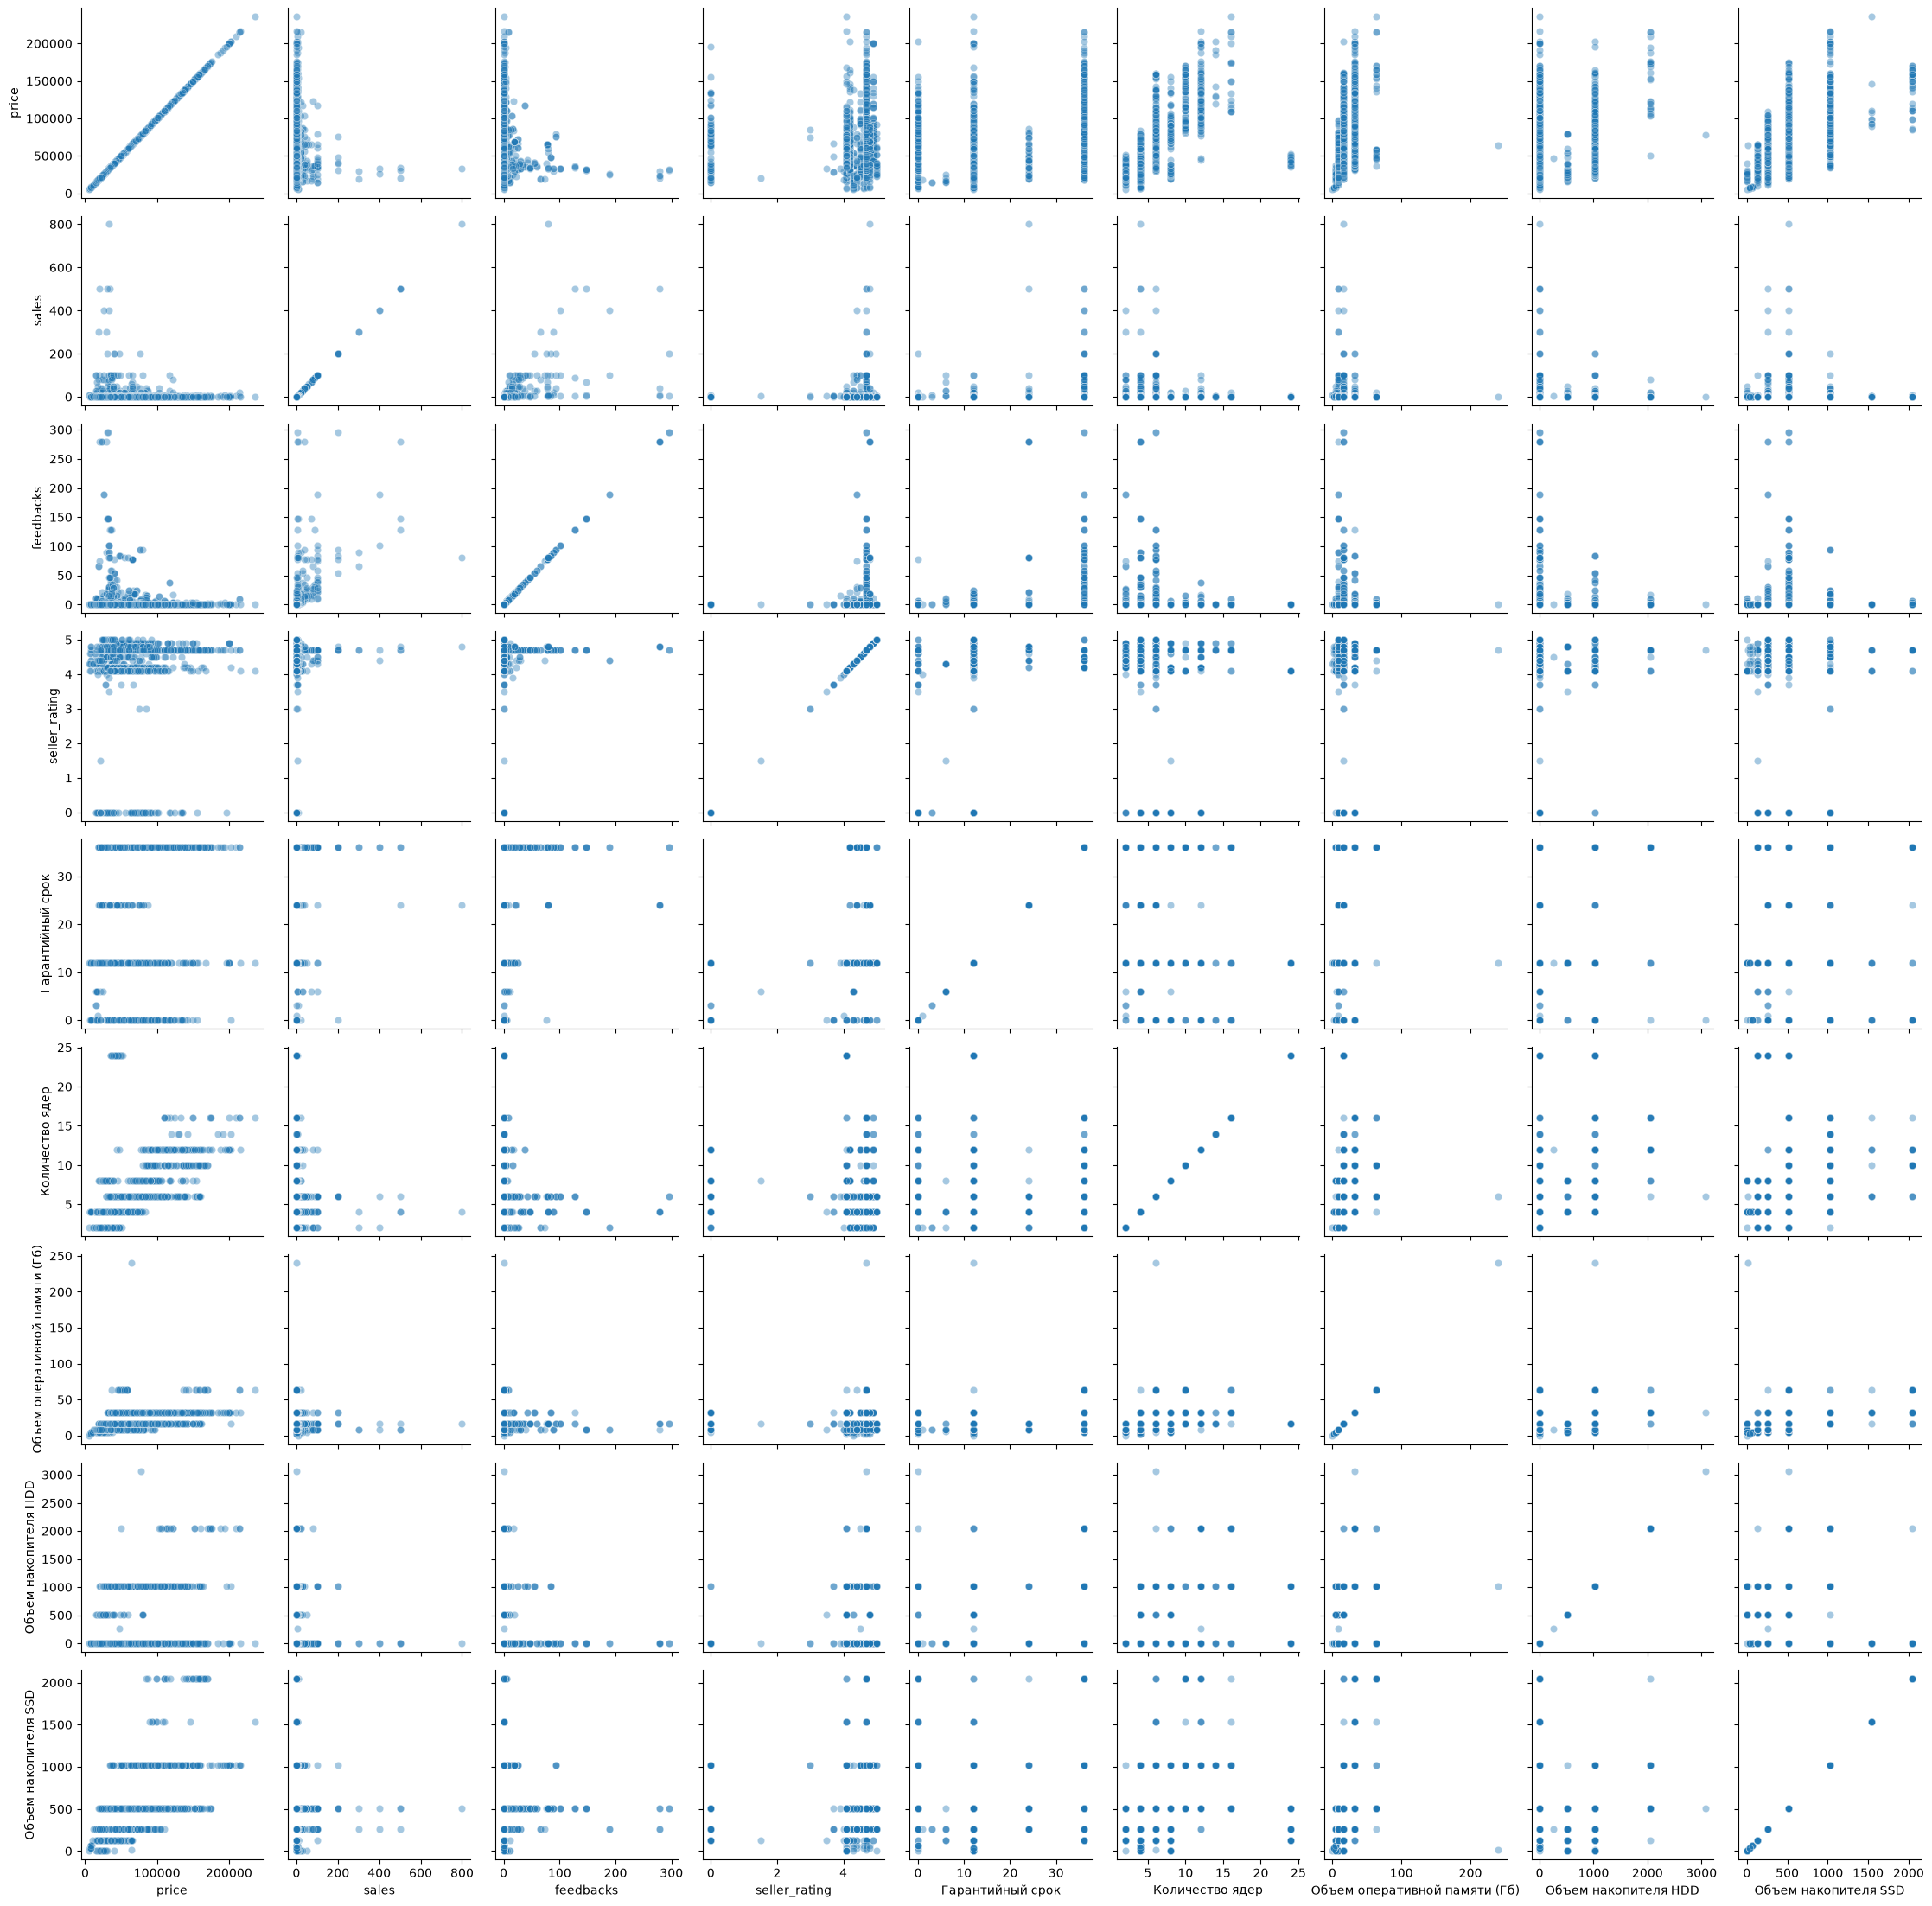

In [ ]:
g = sns.PairGrid(df)
g.map(sns.scatterplot, alpha = 0.4)

## Анализ категориальных признаков

Выведем .value_counts() для всех категориальных признаков.

In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(f"Признак: {col}")
    print(df[col].value_counts())
    print('____________________________')

Признак: seller
seller
Robotcomp                         543
D-Tora                            258
COMPDAY.RU                        206
Roo24.ru                          201
Buchok                            149
I-GAMEZ КОМПЬЮТЕРЫ                100
KING KOMP                          75
M-Bit                              52
Континент                          47
ЖЕЛЕЗНЫЙ ДВОРИК                    34
ЗЕОН                               28
4T-Computer Store                  26
ABS-TECHNO.RU                      17
System Point                       12
KSKSHOP                             9
ALFA-SYSTEM                         9
Москомпьютер                        7
Market-77.ru                        6
Control PC                          5
megamarket                          5
Innopax                             4
Техноцентр                          4
MERKA                               4
TOPIFY                              3
DECK                                3
UNiService                 

C:\Users\Artem\AppData\Local\Temp\ipykernel_16228\2894787334.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


Проверим зависимость категориальных признаков от целевого признака. Для каждого построим boxplot, проверим нормальность и используем статистический критерий.

## Цена -> Операционная система

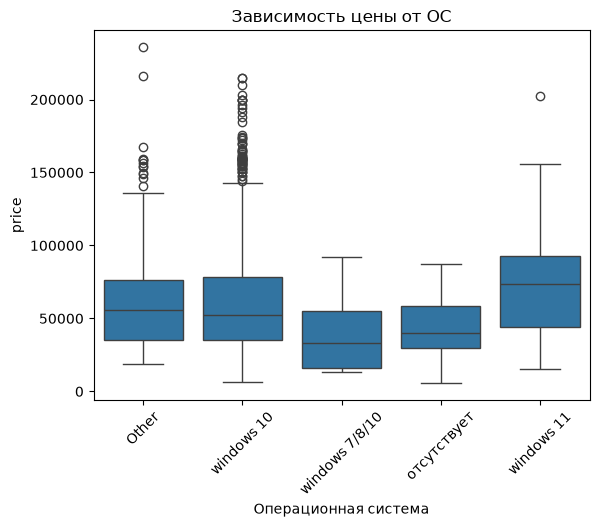

In [ ]:
sns.boxplot(x='Операционная система', y='price', data=df)
plt.title('Зависимость цены от ОС')
plt.xticks(rotation=45)
plt.show()

In [ ]:
for name, group in df.groupby('Операционная система'):
    stat, p = shapiro(group['price'])
    print(f'{name}: p = {p:.4f}')

Other: p = 0.0000
windows 10: p = 0.0000
windows 11: p = 0.0074
windows 7/8/10: p = 0.0077
отсутствует: p = 0.1227


Данные в группах не нормальны, будем использовать Критерий Краскела — Уоллиса

In [ ]:
groups = [group["price"].values for name, group in df.groupby("Операционная система")]
stat, p = kruskal(*groups)

print(f"Kruskal-Wallis: H = {stat:.4f}, p = {p:.4f}")

Kruskal-Wallis: H = 35.2899, p = 0.0000


Есть статистически значимые различия в цене между разными группами операционных систем.

## Цена -> Тип процессора

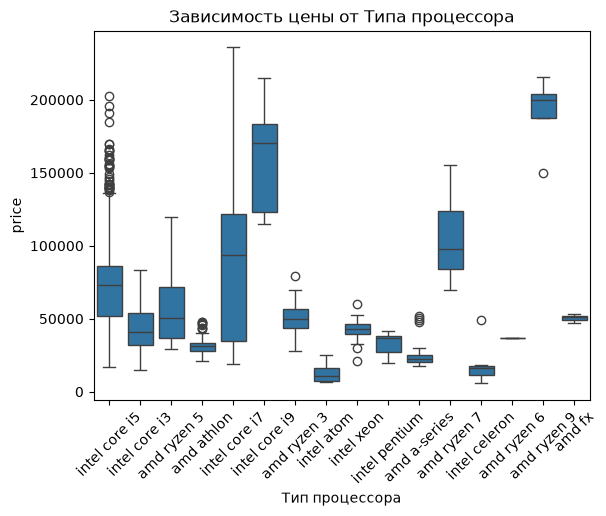

In [ ]:
sns.boxplot(x='Тип процессора', y='price', data=df)
plt.title('Зависимость цены от Типа процессора')
plt.xticks(rotation=45)
plt.show()

In [ ]:
for name, group in df.groupby('Тип процессора'):
    stat, p = shapiro(group['price'])
    print(f'{name}: p = {p:.4f}')

amd a-series: p = 0.0000
amd athlon: p = 0.0003
amd fx: p = 0.6369
amd ryzen 3: p = 0.4271
amd ryzen 5: p = 0.0000
amd ryzen 6: p = nan
amd ryzen 7: p = 0.1076
amd ryzen 9: p = 0.1754
intel atom: p = 0.0008
intel celeron: p = 0.0023
intel core i3: p = 0.0000
intel core i5: p = 0.0000
intel core i7: p = 0.0000
intel core i9: p = 0.0935
intel pentium: p = 0.0118
intel xeon: p = 0.0068


C:\Users\Artem\AppData\Local\Temp\ipykernel_16228\3202827830.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = shapiro(group['price'])


Опять используем Критерий Краскела — Уоллиса

In [ ]:
groups = [group["price"].values for name, group in df.groupby("Тип процессора")]
stat, p = kruskal(*groups)

print(f"Kruskal-Wallis: H = {stat:.4f}, p = {p:.4f}")

Kruskal-Wallis: H = 589.6535, p = 0.0000


Между типами процессоров есть статистически значимые различия в цене.

## Цена -> Тип оперативной памяти

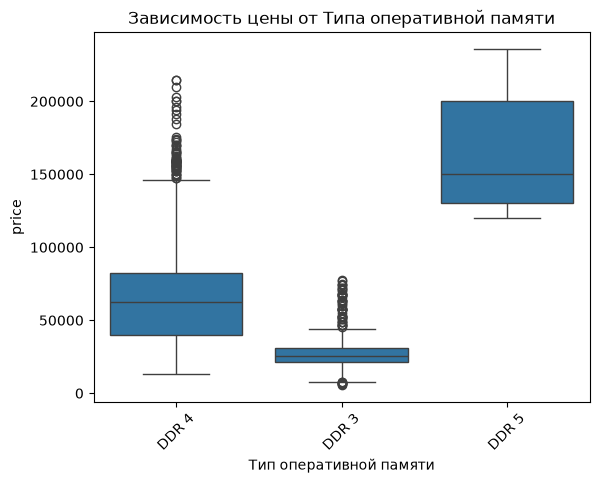

In [ ]:
sns.boxplot(x='Тип оперативной памяти', y='price', data=df)
plt.title('Зависимость цены от Типа оперативной памяти')
plt.xticks(rotation=45)
plt.show()

In [ ]:
for name, group in df.groupby('Тип оперативной памяти'):
    stat, p = shapiro(group['price'])
    print(f'{name}: p = {p:.4f}')

DDR 3: p = 0.0000
DDR 4: p = 0.0000
DDR 5: p = 0.0521


Опять используем Критерий Краскела — Уоллиса

In [ ]:
groups = [group["price"].values for name, group in df.groupby("Тип оперативной памяти")]
stat, p = kruskal(*groups)

print(f"Kruskal-Wallis: H = {stat:.4f}, p = {p:.4f}")

Kruskal-Wallis: H = 491.1333, p = 0.0000


Между типами оперативной памяти есть статистически значимые различия в цене.

## Цена -> Видеопроцессор

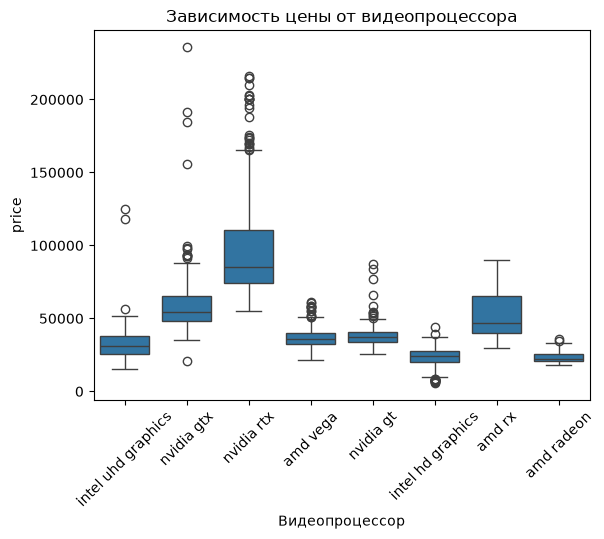

In [ ]:
sns.boxplot(x='Видеопроцессор', y='price', data=df)
plt.title('Зависимость цены от видеопроцессора')
plt.xticks(rotation=45)
plt.show()

In [ ]:
for name, group in df.groupby('Видеопроцессор'):
    stat, p = shapiro(group['price'])
    print(f'{name}: p = {p:.4f}')

amd radeon: p = 0.0018
amd rx: p = 0.0000
amd vega: p = 0.0000
intel hd graphics: p = 0.0000
intel uhd graphics: p = 0.0000
nvidia gt: p = 0.0000
nvidia gtx: p = 0.0000
nvidia rtx: p = 0.0000


In [ ]:
groups = [group["price"].values for name, group in df.groupby("Видеопроцессор")]
stat, p = kruskal(*groups)

print(f"Kruskal-Wallis: H = {stat:.4f}, p = {p:.4f}")

Kruskal-Wallis: H = 1533.9312, p = 0.0000


Между видеопроцессорами есть статистически значимые различия в цене.

## Цена -> Страна производства

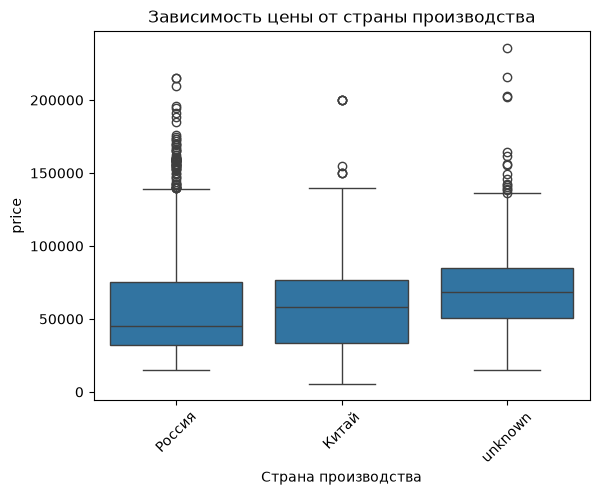

In [ ]:
sns.boxplot(x='Страна производства', y='price', data=df)
plt.title('Зависимость цены от страны производства')
plt.xticks(rotation=45)
plt.show()

In [ ]:
for name, group in df.groupby('Видеопроцессор'):
    stat, p = shapiro(group['price'])
    print(f'{name}: p = {p:.4f}')

amd radeon: p = 0.0018
amd rx: p = 0.0000
amd vega: p = 0.0000
intel hd graphics: p = 0.0000
intel uhd graphics: p = 0.0000
nvidia gt: p = 0.0000
nvidia gtx: p = 0.0000
nvidia rtx: p = 0.0000


In [ ]:
groups = [group["price"].values for name, group in df.groupby("Страна производства")]
stat, p = kruskal(*groups)

print(f"Kruskal-Wallis: H = {stat:.4f}, p = {p:.4f}")

Kruskal-Wallis: H = 103.2180, p = 0.0000


Между странами производства есть статистически значимые различия в цене

## Цена -> Продавец

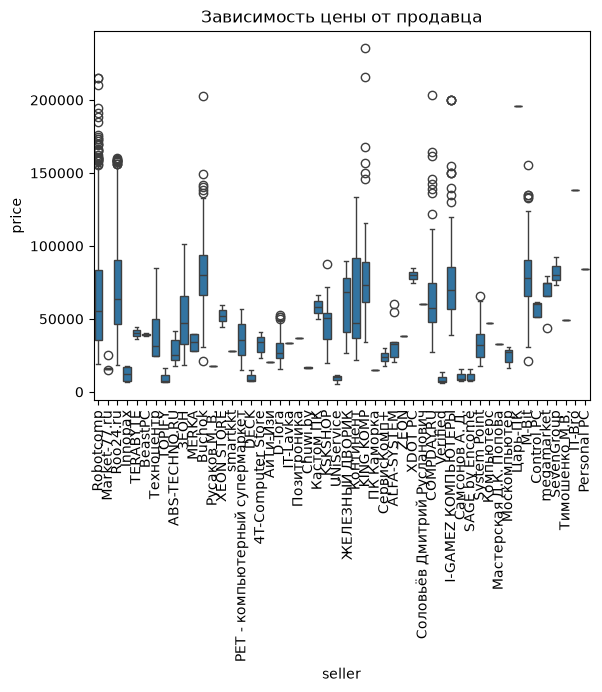

In [ ]:
sns.boxplot(x='seller', y='price', data=df)
plt.title('Зависимость цены от продавца')
plt.xticks(rotation=90)
plt.show()

Невозможно провести анализ без очистки данных. Проведем анализ позже, после кодирования признака 'seller'.

# Шаг 3: Построение модели и стат. анализ

## Кодирование признака "seller"

Для кодировки seller и других категориальных признаков, применим сглаженный target encode. Но для улучшения показателей модели, я сделаю rare-группы по продавцам, потому что таргет плохо работает с одиночными значениями.

df

In [ ]:
df

,price,sales,feedbacks,seller,seller_rating,Видеопроцессор,Операционная система,Гарантийный срок,Страна производства,Тип процессора,Количество ядер,Тип оперативной памяти,Объем оперативной памяти (Гб),Объем накопителя HDD,Объем накопителя SSD
0,39237.0,10,1,Robotcomp,4.7,intel uhd graphics,Other,36,Россия,intel core i5,6,DDR 4,8,0,512
1,76188.0,200,94,Robotcomp,4.7,nvidia gtx,Other,36,Россия,intel core i5,6,DDR 4,16,0,1024
2,55625.0,40,12,Robotcomp,4.7,nvidia gtx,Other,36,Россия,intel core i5,6,DDR 4,16,0,512
3,128284.0,5,4,Robotcomp,4.7,nvidia rtx,Other,36,Россия,intel core i5,10,DDR 4,16,0,1024
4,48386.0,30,9,Robotcomp,4.7,nvidia gtx,Other,36,Россия,intel core i3,4,DDR 4,16,0,512
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1848,21800.0,0,0,ABS-TECHNO.RU,4.4,intel hd graphics,windows 10,36,unknown,intel core i5,2,DDR 3,8,0,256
1849,138190.0,0,0,IT-Bro,4.3,nvidia rtx,windows 11,12,Китай,intel core i5,6,DDR 4,16,0,512
1850,20315.0,0,0,ABS-TECHNO.RU,4.4,intel hd graphics,windows 10,12,Россия,intel core i3,2,DDR 3,8,0,256
1851,21988.0,0,0,ABS-TECHNO.RU,4.4,intel hd graphics,windows 10,12,Россия,intel core i3,2,DDR 3,8,0,512


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1853 entries, 0 to 1852
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   price                          1853 non-null   float64
 1   sales                          1853 non-null   int64  
 2   feedbacks                      1853 non-null   int64  
 3   seller                         1853 non-null   str    
 4   seller_rating                  1853 non-null   float64
 5   Видеопроцессор                 1853 non-null   str    
 6   Операционная система           1853 non-null   str    
 7   Гарантийный срок               1853 non-null   int64  
 8   Страна производства            1853 non-null   str    
 9   Тип процессора                 1853 non-null   str    
 10  Количество ядер                1853 non-null   int64  
 11  Тип оперативной памяти         1853 non-null   str    
 12  Объем оперативной памяти (Гб)  1853 non-null   int64  
 13 

In [ ]:
print(df.groupby('seller')['price'].count().sort_values(ascending = False))

seller
Robotcomp                         543
D-Tora                            258
COMPDAY.RU                        206
Roo24.ru                          201
Buchok                            149
I-GAMEZ КОМПЬЮТЕРЫ                100
KING KOMP                          75
M-Bit                              52
Континент                          47
ЖЕЛЕЗНЫЙ ДВОРИК                    34
ЗЕОН                               28
4T-Computer Store                  26
ABS-TECHNO.RU                      17
System Point                       12
KSKSHOP                             9
ALFA-SYSTEM                         9
Москомпьютер                        7
Market-77.ru                        6
Control PC                          5
megamarket                          5
Innopax                             4
MERKA                               4
Техноцентр                          4
Самсонов А. Д.                      3
Verified                            3
UNiService                          3
TOPIF

Создам 2 дополнительных категории: extra-rare(1-3) и rare(4-9).

In [ ]:
counts = df['seller'].value_counts()
df['seller'] = df['seller'].apply(
    lambda s: 'extra_rare' if counts[s] <= 3
    else 'rare' if counts[s] <= 9
    else s
)

In [ ]:
print(df['seller'].value_counts())

seller
Robotcomp             543
D-Tora                258
COMPDAY.RU            206
Roo24.ru              201
Buchok                149
I-GAMEZ КОМПЬЮТЕРЫ    100
KING KOMP              75
rare                   53
extra_rare             52
M-Bit                  52
Континент              47
ЖЕЛЕЗНЫЙ ДВОРИК        34
ЗЕОН                   28
4T-Computer Store      26
ABS-TECHNO.RU          17
System Point           12
Name: count, dtype: int64


Вернемся к незаконченному анализу заивисимости целевого признака от продавца.

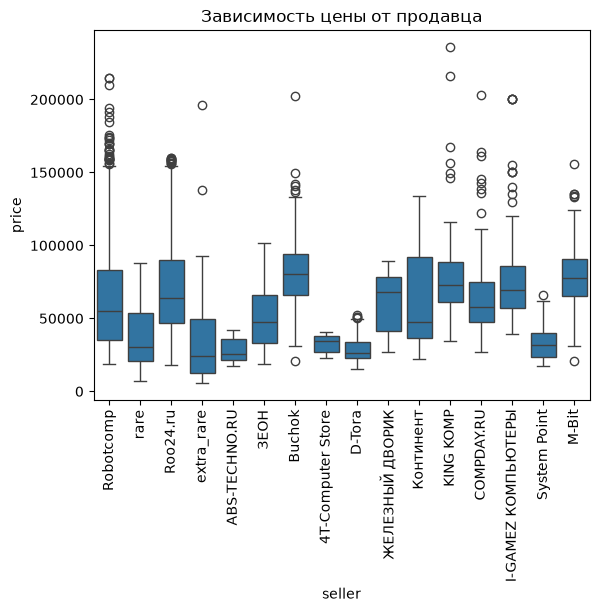

In [ ]:
sns.boxplot(x='seller', y='price', data=df)
plt.title('Зависимость цены от продавца')
plt.xticks(rotation=90)

plt.show()

In [ ]:
for name, group in df.groupby('seller'):
    stat, p = shapiro(group['price'])
    print(f'{name}: p = {p:.4f}')

4T-Computer Store: p = 0.0224
ABS-TECHNO.RU: p = 0.0229
Buchok: p = 0.0001
COMPDAY.RU: p = 0.0000
D-Tora: p = 0.0000
I-GAMEZ КОМПЬЮТЕРЫ: p = 0.0000
KING KOMP: p = 0.0000
M-Bit: p = 0.0361
Robotcomp: p = 0.0000
Roo24.ru: p = 0.0000
System Point: p = 0.1117
extra_rare: p = 0.0000
rare: p = 0.0017
ЖЕЛЕЗНЫЙ ДВОРИК: p = 0.0241
ЗЕОН: p = 0.1611
Континент: p = 0.0002


Данные не подчиняются нормальному закону распределения. Используем критерий Краскела-Уоллиса.

In [ ]:
groups = [group["price"].values for name, group in df.groupby("seller")]
stat, p = kruskal(*groups)

print(f"Kruskal-Wallis: H = {stat:.4f}, p = {p:.4f}")

Kruskal-Wallis: H = 679.6273, p = 0.0000


Между продавцами есть статистически значимые различия в цене

## VIF-анализ

Проведем анализ мультиколлинеарности с помощью VIF (variance inflation factor).

In [ ]:
num_df = df[['sales', 'feedbacks', 'seller_rating', 'Гарантийный срок', 'Количество ядер', 'Объем оперативной памяти (Гб)', 'Объем накопителя HDD', 'Объем накопителя SSD']]

vif_data = pd.DataFrame()
vif_data["feature"] = num_df.columns
vif_data["VIF"] = [variance_inflation_factor(num_df.values, i) for i in range(num_df.shape[1])]
vif_data

,feature,VIF
0,sales,1.415051
1,feedbacks,1.425598
2,seller_rating,1.169324
3,Гарантийный срок,1.287715
4,Количество ядер,1.171131
5,Объем оперативной памяти (Гб),1.407429
6,Объем накопителя HDD,1.294516
7,Объем накопителя SSD,1.417987


У seller_rating VIF очень большое. Удалим из датасета.

In [ ]:
df.drop(columns = 'seller_rating', inplace = True)

## Трансформации box-cox и  yeo johnson'a

### Box-cox

Поскольку модель линейной регресси работает лучше с нормально распределенными данными, применим трансформации.

Для начала, проверим нормальность

In [ ]:
numeric = ['price', 'sales', 'feedbacks', 'Гарантийный срок', 'Количество ядер', 'Объем оперативной памяти (Гб)',	'Объем накопителя HDD',	'Объем накопителя SSD']

for col in numeric:
  check_normality(col, df)

Не нормальное
Не нормальное
Не нормальное
Не нормальное
Не нормальное
Не нормальное
Не нормальное
Не нормальное


Во всех не нормальное распределение, применим трансформации.

In [ ]:
df[numeric].describe()

,price,sales,feedbacks,Гарантийный срок,Количество ядер,Объем оперативной памяти (Гб),Объем накопителя HDD,Объем накопителя SSD
count,1853.000000,1853.000000,1853.000000,1853.000000,1853.000000,1853.000000,1853.000000,1853.000000
mean,61467.590934,7.037237,4.534269,24.052348,6.410146,17.487318,311.538046,516.118726
std,35957.385470,35.697194,22.175535,13.749886,4.090782,11.384810,490.423569,355.130437
min,5672.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000
25%,34858.000000,0.000000,0.000000,12.000000,4.000000,8.000000,0.000000,256.000000
50%,53000.000000,0.000000,0.000000,36.000000,6.000000,16.000000,0.000000,512.000000
75%,78270.000000,5.000000,1.000000,36.000000,6.000000,16.000000,1024.000000,512.000000
max,235900.000000,800.000000,296.000000,36.000000,24.000000,240.000000,3072.000000,2048.000000


Для количества ядер используем Box-cox, так как значения больше 0, а для остальных -  yeo johnson'а, так как он способен обрабатывать нулевые значения.

Очень важно сохранять лямбду, так как если этого не сделать, то не получится строить предсказания  на новых данных

In [ ]:
df['Количество ядер_bc'], boxcox_lambda = boxcox(df['Количество ядер'].dropna()) #сохраняем лямбду, чтобы закодировать новые данные

### Yeo-Johnson

Для остальных количественных признаков применим yeo johnson'a

In [ ]:
numeric.remove("Количество ядер")

Тут тоже важно сохранить объекты трансформеров, чтобы кодировать новые данные.

In [ ]:
transformers = {}

for col in numeric:
    pt = PowerTransformer(method='yeo-johnson')
    df[f'{col}_yj'] = pt.fit_transform(df[[col]])
    transformers[col] = pt  # сохраняем трансформер, чтобы потом использовать

In [ ]:
numeric.append('Количество ядер') #добавляем обратно, чтобы удалить из датасета
df.drop(columns=numeric, inplace = True)

## Target encode категориальных признаков

Тут особенно важно сохранить глобальные средние по признакам и объекты-маппинги по признакам.

In [ ]:
category = ['Видеопроцессор', 'Операционная система', 'Страна производства', 'Тип процессора', 'Тип оперативной памяти', 'seller']

mappings_all = {} #сохраняем маппинги
global_means_all = {} #сохраняем глобальные средние

for col in category:
    df, mappings, global_mean = target_encode(df, col=col, target='price_yj')
    df.drop(columns=col, inplace=True)
    mappings_all[col] = mappings
    global_means_all[col] = global_mean

In [ ]:
df.describe()

,Количество ядер_bc,price_yj,sales_yj,feedbacks_yj,Гарантийный срок_yj,Объем оперативной памяти (Гб)_yj,Объем накопителя HDD_yj,Объем накопителя SSD_yj,Видеопроцессор_te,Операционная система_te,Страна производства_te,Тип процессора_te,Тип оперативной памяти_te,seller_te
count,1853.000000,1.853000e+03,1.853000e+03,1.853000e+03,1.853000e+03,1.853000e+03,1853.000000,1.853000e+03,1853.000000,1853.000000,1853.000000,1853.000000,1853.000000,1853.000000
mean,1.402140,-1.610512e-15,-3.067643e-17,-9.202928e-17,-3.451098e-16,-3.221025e-16,0.000000,-2.224041e-16,0.000381,-0.000801,-0.000797,-0.009394,-0.008888,0.004511
std,0.331511,1.000270e+00,1.000270e+00,1.000270e+00,1.000270e+00,1.000270e+00,1.000270,1.000270e+00,0.878481,0.150442,0.212224,0.550255,0.506652,0.589851
min,0.640796,-3.446774e+00,-7.550493e-01,-5.942897e-01,-1.843628e+00,-4.884755e+00,-0.675786,-2.938876e+00,-1.445529,-0.955846,-0.252191,-2.605657,-1.169736,-1.378855
25%,1.187297,-7.178476e-01,-7.550493e-01,-5.942897e-01,-8.284590e-01,-1.095078e+00,-0.675786,-7.132355e-01,-0.641323,-0.008610,-0.119107,-0.440815,0.208458,-0.009591
50%,1.468898,-8.007993e-03,-7.550493e-01,-5.942897e-01,8.579669e-01,9.157978e-02,-0.675786,1.742414e-01,0.094740,-0.005537,-0.114737,-0.008862,0.209484,0.164992
75%,1.468898,6.820906e-01,1.185905e+00,1.153796e+00,8.579669e-01,9.157978e-02,1.485961,1.742414e-01,0.993016,0.003118,-0.091747,0.364440,0.209660,0.370819
max,2.255697,2.800752e+00,1.825026e+00,1.998560e+00,8.579669e-01,5.519973e+00,1.550223,3.049916e+00,1.024217,0.496529,0.372467,1.518573,1.805506,0.736873


## Анализ влияния признаков на 'sales'

Я выбрал построение регрессионной модели (OLS), потому что она позволяет не просто выявить связи между признаками и продажами, а оценить величину и значимость каждого фактора с учётом влияния других переменных. В отличие от простого статистического анализа, модель учитывает многомерность данных и помогает выявить независимые эффекты, что важно для принятия обоснованных бизнес-решений по оптимизации ассортимента и ценообразования.

In [ ]:
X_sales_yj = df.drop(columns=['sales_yj'])
y_sales_yj = df['sales_yj']

X_train_sales_yj, X_test_sales_yj, y_train_sales_yj, y_test_sales_yj = train_test_split(
    X_sales_yj, y_sales_yj, test_size=0.2, random_state=42
)

model_sales_yj = LinearRegression()
model_sales_yj.fit(X_train_sales_yj, y_train_sales_yj)

X_train_const_sales_yj = sm.add_constant(X_train_sales_yj)

model_sm_sales_yj = sm.OLS(y_train_sales_yj, X_train_const_sales_yj).fit()

print(model_sm_sales_yj.summary())

                            OLS Regression Results                            
Dep. Variable:               sales_yj   R-squared:                       0.490
Model:                            OLS   Adj. R-squared:                  0.485
Method:                 Least Squares   F-statistic:                     108.3
Date:                Wed, 07 Oct 2026   Prob (F-statistic):          1.69e-203
Time:                        21:58:25   Log-Likelihood:                -1597.7
No. Observations:                1482   AIC:                             3223.
Df Residuals:                    1468   BIC:                             3298.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

Наблюдаем, что 'price_yj' имеет отрицательный и сильный коэффициент — с ростом цены продажи падают.

Гарантия, объем оперативной памяти, SSD и тип процессора — все они показывают положительный и статистически значимый эффект на продажи.

## Обучение модели линейной регрессии(продажи)

### Итерация 1: никакие признаки исключены не были

In [ ]:
X = df.drop(columns=['price_yj']) #создаем датасет без целевого признака
y = df['price_yj'] #отдельный  датасет целевого признака

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #разбиваем датасет на тест и треин подгруппы

model = LinearRegression() #создаем модель
model.fit(X_train, y_train) #обучаем модель

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 0.21,-0. ,-0.07,..., 0.33, 0.03, 0.15]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['Количество ядер_bc','sales_yj','feedbacks_yj',...,'Тип процессора_te', 'Тип оперативной памяти_te','seller_te']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.2971
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)


Метрики модели

In [ ]:
X_train_const = sm.add_constant(X_train)

model_sm = sm.OLS(y_train, X_train_const).fit()

print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:               price_yj   R-squared:                       0.894
Model:                            OLS   Adj. R-squared:                  0.893
Method:                 Least Squares   F-statistic:                     951.2
Date:                Wed, 07 Oct 2026   Prob (F-statistic):               0.00
Time:                        21:58:25   Log-Likelihood:                -433.25
No. Observations:                1482   AIC:                             894.5
Df Residuals:                    1468   BIC:                             968.7
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

Обратим внимание на то, что 'Тип оперативной памяти_te','Страна производства_te' ,'Операционная система_te', 'feedbacks_yj' имеют p-value больше  0.05. Значит их можно  удалить из модели без потери качества. **Обращаю внимание**: поскольку данные были многократно обработаны, R² нельзя доверять! для истинного R² нужно преобразовать целевой признак обратно! (сделать inv_uj)

In [ ]:
y_pred = model.predict(X_test)

y_pred_df = pd.DataFrame(y_pred, columns=["price"])
y_pred_real = transformers['price'].inverse_transform(y_pred_df).flatten()

y_test_df = pd.DataFrame(y_test.values, columns=["price"])
y_test_real = transformers['price'].inverse_transform(y_test_df).flatten()

print("R² (original scale):", r2_score(y_test_real, y_pred_real))
print("MAE (original scale):",  mean_absolute_error(y_test_real, y_pred_real))
print("RMSE (original scale):", np.sqrt(mean_squared_error(y_test_real, y_pred_real)))

R² (original scale): 0.7866053659218146
MAE (original scale): 9834.284933067529
RMSE (original scale): 17747.564544695448


### Итерация 2: исключаем 4 признака

In [ ]:
df_copy = df.copy()

In [ ]:
df.drop(columns = ['Тип оперативной памяти_te','Страна производства_te' ,'Операционная система_te', 'feedbacks_yj'], inplace = True)

In [ ]:
X = df.drop(columns=['price_yj'])
y = df['price_yj']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[ 0.21,-0.05, 0.09,..., 0.66, 0.32, 0.15]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['Количество ядер_bc','sales_yj','Гарантийный срок_yj',..., 'Видеопроцессор_te','Тип процессора_te','seller_te']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.2974
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)


Метрики модели

In [ ]:
X_train_const = sm.add_constant(X_train)

model_sm = sm.OLS(y_train, X_train_const).fit()

print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:               price_yj   R-squared:                       0.891
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                     1339.
Date:                Wed, 07 Oct 2026   Prob (F-statistic):               0.00
Time:                        21:58:26   Log-Likelihood:                -452.16
No. Observations:                1482   AIC:                             924.3
Df Residuals:                    1472   BIC:                             977.3
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

In [ ]:
y_pred = model.predict(X_test)

y_pred_df = pd.DataFrame(y_pred, columns=["price"])
y_pred_real = transformers['price'].inverse_transform(y_pred_df).flatten()

y_test_df = pd.DataFrame(y_test.values, columns=["price"])
y_test_real = transformers['price'].inverse_transform(y_test_df).flatten()

print("R² (original scale):", r2_score(y_test_real, y_pred_real))
print("MAE (original scale):",  mean_absolute_error(y_test_real, y_pred_real))
print("RMSE (original scale):", np.sqrt(mean_squared_error(y_test_real, y_pred_real)))

R² (original scale): 0.7845306791949619
MAE (original scale): 9985.588978377056
RMSE (original scale): 17833.62944003818


Таким образом, мы удалили 4 признака из модели(их было всего 13) и сохранили точность модели

## Анализ остатков

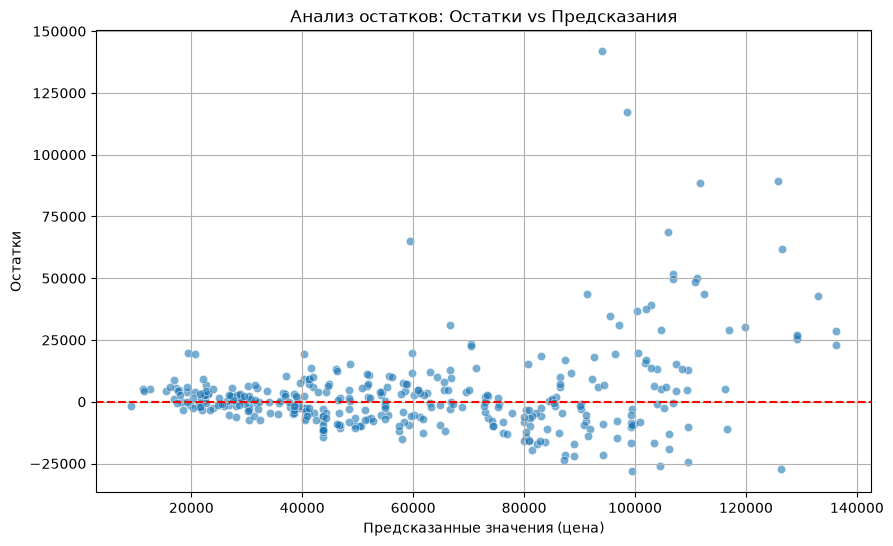

In [ ]:
residuals = y_test_real - y_pred_real
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_real, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Предсказанные значения (цена)")
plt.ylabel("Остатки")
plt.title("Анализ остатков: Остатки vs Предсказания")
plt.grid(True)
plt.show()


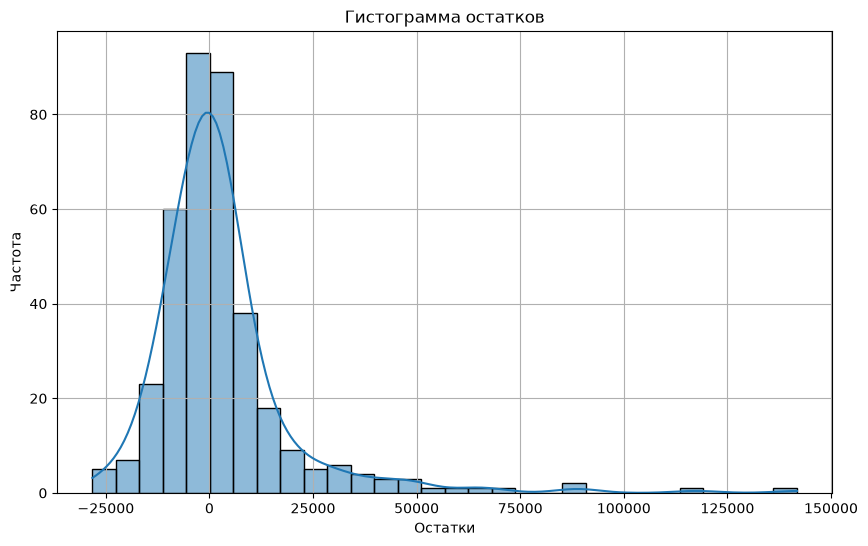

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Гистограмма остатков")
plt.xlabel("Остатки")
plt.ylabel("Частота")
plt.grid(True)
plt.show()

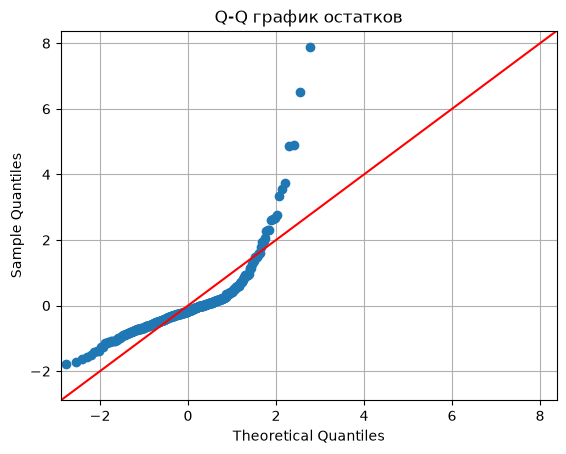

In [ ]:
import scipy.stats as stats
import statsmodels.api as sm

sm.qqplot(residuals, line='45', fit=True)
plt.title("Q-Q график остатков")
plt.grid(True)
plt.show()

In [ ]:
mean_residual = np.mean(residuals)
std_residual = np.std(residuals)

print("Среднее остатка:", mean_residual)
print("Ст. отклонение остатка:", std_residual)

Среднее остатка: 2953.749933851739
Ст. отклонение остатка: 17587.316461952556


# Новый прогноз

In [ ]:
new_predict(
    cores=16,
    sales=121,
    warranty=36,
    RAM=64,
    HDD=2048,
    SSD=2048,
    videocard='nvidia rtx',
    processor = 'intel core i9',
    seller='Robotcomp')

c:\Users\Artem\Desktop\pc-market-analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


'Прогнозируемая цена: 168066.93 руб.'

# Вывод

**На основе регрессионного анализа с использованием модели OLS по признаку 'sales':**
Признак 'price_yj' имеет сильный отрицательный коэффициент — с ростом цены продажи падают.

Гарантия, Объем оперативной памяти, объем SSD и тип процессора — все они показывают положительный и статистически значимый эффект на продажи.

**На основе регрессионного анализа с использованием модели OLS по признаку 'price':**

- **Модель объясняет 89% дисперсии** логарифмированной (Yeo-Johnson) цены (R² = 0.891), что указывает на высокую предсказательную силу.
- На оригинальной шкале R² = **0.784**, что также считается хорошим результатом для рыночных данных.
- **Средняя абсолютная ошибка (MAE)**: ~9 985 руб.  
- **Среднеквадратичная ошибка (RMSE)**: ~17 834 руб.  

Модель даёт приемлемую точность при предсказании стоимости ПК.

Влияние признаков на цену:

| Признак                             |   Влияние на цену   |
|-------------------------------------|---------------------|
| SSD объем                           | сильно влияет       |
| Видеокарта                          | очень сильно влияет |
| Тип процессора                      | значительно         |
| Кол-во ядер                         | ощутимо             |
| ОЗУ (объем)                         | умеренно            |
| HDD объем                           | умеренно            |
| Гарантийный срок                    | слабо               |
| Продавец (seller_te)                | слабо, но значимо   |
| Кол-во продаж (sales)               | отрицательно (!)    |

Примечание: отрицательное влияние **sales** на цену, скорее всего, говорит о том, что более дешёвые модели продаются лучше — типичная картина для маркетплейсов.

Рекомендации для клиента:

1. **Фокус на видеокарту и SSD**  
   → Эти параметры больше всего влияют на цену. Для создания более дорогих моделей — мощная GPU + минимум 512 ГБ SSD.  

2. **Оптимальный баланс по CPU и RAM**  
   → Не всегда топовые процессоры оправдывают цену. Лучше 6–8 ядер с современным поколением и 16–32 ГБ ОЗУ.

3. **HDD — как дополнение**  
   → Наличие большого HDD влияет на цену, но не критично. Можно использовать как “плюс” в описании.

4. **Акцент на выгодную цену**  
   → Популярные ПК чаще стоят дешевле. Подумать о двух линейках: «доступная» и «премиум».

5. **Использовать сильных продавцов**  
   → Продавец влияет на цену — возможно из-за доверия бренду. При выходе на маркетплейс — важно иметь качественный рейтинг.

6. **Визуализировать комплектацию**  
   → Использовать эти выводы для маркетинговых карточек товара. Подсвечивать SSD, GPU, CPU в первых строках.

 Регрессионная модель позволила выявить ключевые факторы, влияющие на цену ПК на маркетплейсах. Эти знания можно использовать для построения ассортимента и определения конкурентных цен на продукцию клиента.

